# RB：全合约持仓量、成交量与主力双幂变差的历年变化

**研究问题：螺纹钢全合约持仓量、成交量与主力价格序列的每日双幂变差如何随年份变化，是否呈现肉眼可见的长期下降？**

第 1—5 节分析成交量；第 6—8 节分析每日双幂变差 $BV_d=(\pi/2)\sum_i |r_{d,i-1}||r_{d,i}|$。第 9 节加总 RB 全部真实合约的收盘持仓量与成交量，第 10 节展示全合约持仓量、全合约成交量和主力每日 BV 的日频曲线与年度柱状图，第 11 节比较换约附近的变化，第 12 节展示分钟成交量与双幂变差分钟贡献项的对数联合分布。主力成交量和 BV 使用同一份 RB 主力映射快照。

本 Notebook 面向理解主力合约、成交量和滚动均值的研究者。样本采用
`testing_10/testing_10_rb_main_minute.parquet` 已保存的主力合约映射，本分析仅使用 **2015—2025 年**的交易日；
成交量取正式 silver 日线表中该真实合约在该交易日的 `volume`，单位为手。
第 1—5 节为每天选定的**单个主力合约成交量**；第 9 节分别加总同一交易日 **RB 全部真实合约的成交量与收盘持仓量**。
持仓量使用正式日线字段 `open_interest`，单位为手；年度持仓柱状图表示全年交易日收盘持仓量的平均值。

主力选择使用上一交易日成交量，向更晚到期合约移仓的成交量阈值为 1.10 倍；完整选择过程见
[testing_10.ipynb](testing_10.ipynb)。成交量按真实合约直接拼接，不乘价格复权因子，
也不对分钟成交量求和，以免分钟缺失使日成交量偏低。

依次运行全部单元格，查看日频曲线、60／252 个交易日移动均值、全年日均与中位数。
年度比较使用每年 1 月 1 日至 12 月 31 日内的全部交易日。
本分析保持来源历史计量口径；图形和描述性变动不等同于统计显著性检验，也不识别变化原因。

**跨 2020 年的口径边界：**中国期货业协会说明，三家商品期货交易所在 2020 年以前按双边统计成交量，
自 2020-01-01 起统一按单边统计。见[《单边计量与双边计量》](https://www.cfachina.org/inv/wqbh/rxwd/202302/t20230208_36029.html)。
这条交易所制度说明不能单独证明聚宽是否追溯调整了所有历史数据。本 Notebook 保留湖中来源原值，
不擅自把早年成交量除以二；跨 2020 年的绝对水平和降幅须在核实供应商历史口径后解释。
成交量及其 60／252 日均线按全样本连续绘制，不在 2020 年分段或重新起算；这一展示方式不代表历史计量口径已经统一。


文件输出：图表和表格默认保留在 Notebook 内。`EXPORT_FILES = True` 时，独立图片统一保存到 `testing_12/`；默认运行不创建这些独立文件。

In [1]:
from __future__ import annotations

import pathlib
import sys

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()  # 当前工作目录

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        sys.path.insert(0, str(candidate_root / "02_Market_Data/a01_Collection"))
        break
else:
    raise RuntimeError("未找到项目根目录")

from config.settings import settings
from config.data_contracts import FUTURES_DAILY_SCHEMA, validate_arrow_table, arrow_to_pandas
from b00_03_notebook_schema_browser import display_schema_metadata

DAILY_TABLE_NAME = FUTURES_DAILY_SCHEMA.metadata[b"table_name"].decode("utf-8")
DAILY_PRIMARY_KEY = FUTURES_DAILY_SCHEMA.metadata[b"primary_key"].decode("utf-8").split(",")
DAILY_PARTITION_COLUMNS = FUTURES_DAILY_SCHEMA.metadata[b"partition_columns"].decode("utf-8").split(",")

ANALYSIS_START_DATE = "2015-01-01"
ANALYSIS_END_DATE = "2025-12-31"
SHORT_WINDOW = 60
LONG_WINDOW = 252
notebook_dir = candidate_root / "00_draft_collection_01"
output_dir = notebook_dir / "testing_12"
EXPORT_FILES = False  # 图表默认内嵌；需要独立文件时显式设为 True。
if EXPORT_FILES:
    output_dir.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print(f"解释器：{sys.executable}")

解释器：E:\anaconda3\envs\latitude_env_v2\python.exe


## 1. 日线数据契约与已有主力映射

下方展示本分析直接读取的正式日线表契约。分钟快照属于 testing_10 的研究输出，
在成交量分析中用于取得主力合约映射，在分钟收益分析中提供复权对数价格；正式日线读取通过权威 Arrow Schema 校验与转换。

In [2]:
display_schema_metadata([FUTURES_DAILY_SCHEMA])

### 读取 RB 主力连续分钟快照

读取 `testing_10/testing_10_rb_main_minute.parquet`，该文件由 `testing_10.ipynb` 从正式湖行情构造，包含主力合约映射和复权结果。读取时按 `trading_date` 限定为 **2015-01-01 至 2025-12-31**；实际记录数和交易日范围由下方单元格输出。

- `bar_at`：分钟时间戳，时区为 `Asia/Shanghai`；`trading_date`：所属交易日，包含归属该日的夜盘。
- `contract_code`：该分钟选定的真实主力合约，选择依据为上一交易日成交量，后月移仓阈值为 1.10 倍。
- `open/high/low/close`：真实合约的原始价格。
- `backward_adjusted_log_close`：锚定序列起点的复权对数收盘价，可用于连续收益计算；`forward_adjusted_log_close` 为锚定末端的版本。

读入后的 DataFrame 名为 `rb_main_minute_df`。

In [3]:
import pandas as pd

rb_main_minute_path = notebook_dir / "testing_10" / "testing_10_rb_main_minute.parquet"

rb_main_minute_df = (
    pd.read_parquet(
        rb_main_minute_path, dtype_backend="pyarrow",
        filters=[
            ("trading_date", ">=", pd.Timestamp(ANALYSIS_START_DATE).date()),
            ("trading_date", "<=", pd.Timestamp(ANALYSIS_END_DATE).date()),
        ],
    )
    .sort_values("bar_at")
    .reset_index(drop=True)
)

print(f"分钟记录：{len(rb_main_minute_df):,}")
print(
    f"交易日范围：{rb_main_minute_df['trading_date'].min()}"
    f" 至 {rb_main_minute_df['trading_date'].max()}"
)

rb_main_minute_df.head()

分钟记录：943,770
交易日范围：2015-01-05 至 2025-12-31


,contract_code,exchange_code,underlying_code,trading_date,session_number,bar_at,open,high,low,close,volume,money,open_interest,source,updated_at,year,month,signal_trading_date,main_contract_code,previous_main_contract_code,continuity_segment,is_roll,selection_reason,main_contract_signal_volume,incumbent_signal_volume,challenger_contract_code,challenger_signal_volume,roll_trigger_ratio,backward_adjusted_log_close,forward_adjusted_log_close
0,RB1505.XSGE,XSGE,RB,2015-01-05,2,2015-01-05 09:01:00+08:00,2550.0,2556.0,2546.0,2554.0,119038.0,3036040820.0,2119948.0,JQData_get_price_1m_skip_paused,2026-08-02 16:15:40+00:00,2015,1,2014-12-31,RB1505.XSGE,RB1505.XSGE,1,False,incumbent_retained,4148900.0,4148900.0,RB1510.XSGE,288258.0,1.1,7.845416,7.378407
1,RB1505.XSGE,XSGE,RB,2015-01-05,2,2015-01-05 09:02:00+08:00,2555.0,2560.0,2555.0,2557.0,73354.0,1876008000.0,2124524.0,JQData_get_price_1m_skip_paused,2026-08-02 16:15:40+00:00,2015,1,2014-12-31,RB1505.XSGE,RB1505.XSGE,1,False,incumbent_retained,4148900.0,4148900.0,RB1510.XSGE,288258.0,1.1,7.84659,7.379581
2,RB1505.XSGE,XSGE,RB,2015-01-05,2,2015-01-05 09:03:00+08:00,2556.0,2558.0,2555.0,2557.0,37466.0,957780520.0,2124716.0,JQData_get_price_1m_skip_paused,2026-08-02 16:15:40+00:00,2015,1,2014-12-31,RB1505.XSGE,RB1505.XSGE,1,False,incumbent_retained,4148900.0,4148900.0,RB1510.XSGE,288258.0,1.1,7.84659,7.379581
3,RB1505.XSGE,XSGE,RB,2015-01-05,2,2015-01-05 09:04:00+08:00,2556.0,2562.0,2556.0,2559.0,50016.0,1280375660.0,2127546.0,JQData_get_price_1m_skip_paused,2026-08-02 16:15:40+00:00,2015,1,2014-12-31,RB1505.XSGE,RB1505.XSGE,1,False,incumbent_retained,4148900.0,4148900.0,RB1510.XSGE,288258.0,1.1,7.847372,7.380363
4,RB1505.XSGE,XSGE,RB,2015-01-05,2,2015-01-05 09:05:00+08:00,2559.0,2559.0,2556.0,2556.0,34832.0,890741660.0,2131518.0,JQData_get_price_1m_skip_paused,2026-08-02 16:15:40+00:00,2015,1,2014-12-31,RB1505.XSGE,RB1505.XSGE,1,False,incumbent_retained,4148900.0,4148900.0,RB1510.XSGE,288258.0,1.1,7.846199,7.37919


## 2. 匹配主力合约的真实日成交量

先从快照提取每个交易日的主力合约，再读取同品种、同日期范围的正式日线。
用日线表中实际存在的品种交易日作为绘图索引，保留快照没有主力映射的日期为空值；
缺失不填零，也不前向填充。每个滚动窗口必须有完整的有效日成交量才能显示均值。

文件物理字段与表身份按权威契约检查；不重做生产者已保证的全湖主键、覆盖和业务验收。
对研究输出则检查每日主力映射唯一、信号日早于成交日及成交量可用于计算。

In [4]:
main_contract_daily_df = rb_main_minute_df[
    ["exchange_code", "underlying_code", "trading_date", "contract_code",
     "main_contract_code", "signal_trading_date", "roll_trigger_ratio"]
].drop_duplicates().reset_index(drop=True)

if main_contract_daily_df.empty:
    raise ValueError("分钟快照没有主力映射。")
if main_contract_daily_df["trading_date"].duplicated().any():
    raise ValueError("快照中同一交易日存在多个主力映射，不能无歧义拼接。")
if not main_contract_daily_df["contract_code"].eq(main_contract_daily_df["main_contract_code"]).all():
    raise ValueError("快照真实合约与主力合约不一致。")
if not (main_contract_daily_df["signal_trading_date"] < main_contract_daily_df["trading_date"]).all():
    raise ValueError("主力映射使用的信号日必须早于目标交易日。")
if main_contract_daily_df[["exchange_code", "underlying_code"]].drop_duplicates().shape[0] != 1:
    raise ValueError("本 Notebook 一次只分析一个品种。")

exchange_code = str(main_contract_daily_df["exchange_code"].iloc[0])
underlying_code = str(main_contract_daily_df["underlying_code"].iloc[0])
sample_start = main_contract_daily_df["trading_date"].min()
sample_end = main_contract_daily_df["trading_date"].max()
daily_filter = (
    (ds.field("exchange_code") == exchange_code)
    & (ds.field("underlying_code") == underlying_code)
    & (ds.field("year") >= sample_start.year)
    & (ds.field("year") <= sample_end.year)
    & (ds.field("trading_date") >= sample_start)
    & (ds.field("trading_date") <= sample_end)
)
rb_daily_dataset = ds.dataset(
    settings.futures_lake_root / "silver" / DAILY_TABLE_NAME,
    format="parquet",
    schema=FUTURES_DAILY_SCHEMA,
    partitioning=ds.partitioning(
        pa.schema([FUTURES_DAILY_SCHEMA.field(name) for name in DAILY_PARTITION_COLUMNS]),
        flavor="hive",
    ),
)

# 分区列可以由目录提供；其余字段、字段顺序、类型和 nullable 必须一致。
for daily_fragment in rb_daily_dataset.get_fragments(filter=daily_filter):
    physical_schema = daily_fragment.physical_schema
    expected_fields = [field for field in FUTURES_DAILY_SCHEMA if field.name not in DAILY_PARTITION_COLUMNS]
    physical_fields = [field for field in physical_schema if field.name not in DAILY_PARTITION_COLUMNS]
    if not pa.schema(physical_fields).equals(pa.schema(expected_fields), check_metadata=False):
        raise ValueError(f"日线文件物理结构不兼容：{daily_fragment.path}")
    for name in DAILY_PARTITION_COLUMNS:
        if name in physical_schema.names and not physical_schema.field(name).equals(
            FUTURES_DAILY_SCHEMA.field(name), check_metadata=False
        ):
            raise ValueError(f"日线分区字段不兼容：{daily_fragment.path} / {name}")
    for metadata_key in [b"table_name", b"primary_key", b"partition_columns", b"schema_version"]:
        if (physical_schema.metadata or {}).get(metadata_key) != FUTURES_DAILY_SCHEMA.metadata[metadata_key]:
            raise ValueError(f"日线文件表身份或契约版本不兼容：{daily_fragment.path}")

rb_daily_table = rb_daily_dataset.to_table(filter=daily_filter)
validated_rb_daily_table = validate_arrow_table(rb_daily_table, FUTURES_DAILY_SCHEMA)
rb_daily_df = arrow_to_pandas(validated_rb_daily_table, FUTURES_DAILY_SCHEMA)

# 日期索引来自正式日线，主力身份来自分钟快照；不按分钟记录数估算日成交量。
sample_dates_df = rb_daily_df[["trading_date"]].drop_duplicates()
main_daily_volume_df = sample_dates_df.merge(
    main_contract_daily_df, on="trading_date", how="outer", validate="one_to_one"
).merge(
    rb_daily_df[[*DAILY_PRIMARY_KEY, "volume", "has_market_data", "source"]],
    on=DAILY_PRIMARY_KEY, how="left", validate="one_to_one",
).sort_values("trading_date").reset_index(drop=True)
main_daily_volume_df["trading_date"] = pd.to_datetime(main_daily_volume_df["trading_date"])
main_daily_volume_df["volume"] = main_daily_volume_df["volume"].where(
    main_daily_volume_df["has_market_data"].fillna(False)
).astype("float64")
valid_volume = main_daily_volume_df["volume"].dropna()
if valid_volume.empty or not np.isfinite(valid_volume).all() or (valid_volume < 0).any():
    raise ValueError("没有可计算的成交量，或成交量包含非有限数／负值。")

for window in [SHORT_WINDOW, LONG_WINDOW]:
    main_daily_volume_df[f"volume_ma_{window}"] = (
        main_daily_volume_df["volume"].rolling(window, min_periods=window).mean()
    )

print(f"{exchange_code}.{underlying_code}：{sample_start} 至 {sample_end}")
print(f"绘图交易日 {len(main_daily_volume_df):,}；有效日成交量 {len(valid_volume):,}；缺失 {main_daily_volume_df['volume'].isna().sum():,}")
print("范围由主力映射快照限定；正式湖后续更新不会自动扩展这份快照。")
display(main_daily_volume_df[["trading_date", "contract_code", "volume", f"volume_ma_{SHORT_WINDOW}", f"volume_ma_{LONG_WINDOW}"]].tail())

XSGE.RB：2015-01-05 至 2025-12-31
绘图交易日 2,674；有效日成交量 2,674；缺失 0
范围由主力映射快照限定；正式湖后续更新不会自动扩展这份快照。


,trading_date,contract_code,volume,volume_ma_60,volume_ma_252
2669,2025-12-25,RB2605.XSGE,502388.0,989535.400000,1.412598e+06
2670,2025-12-26,RB2605.XSGE,1132633.0,993695.700000,1.409067e+06
2671,2025-12-29,RB2605.XSGE,1051146.0,988068.866667,1.407930e+06
2672,2025-12-30,RB2605.XSGE,635547.0,979566.516667,1.406101e+06
2673,2025-12-31,RB2605.XSGE,651840.0,974433.383333,1.402508e+06


## 3. 全年日均成交量与中位数

每个年份使用该年全部交易日的日成交量计算平均值和中位数；两者均不是年度成交总量。
表中列出实际起止交易日、有效天数和缺失天数，年度范围为 2015—2025 年。


In [5]:
annual_volume_df = (
    main_daily_volume_df.assign(year=main_daily_volume_df["trading_date"].dt.year)
    .groupby("year")
    .agg(
        start_date=("trading_date", "min"), end_date=("trading_date", "max"),
        sample_days=("trading_date", "size"), valid_days=("volume", "count"),
        mean_volume=("volume", "mean"), median_volume=("volume", "median"),
    )
)
annual_volume_df["missing_days"] = annual_volume_df["sample_days"] - annual_volume_df["valid_days"]
annual_volume_df["mean_change_pct"] = annual_volume_df["mean_volume"].pct_change(fill_method=None) * 100
annual_display_df = annual_volume_df.assign(
    mean_volume=annual_volume_df["mean_volume"] / 10000,
    median_volume=annual_volume_df["median_volume"] / 10000,
).rename(columns={
    "start_date": "首个交易日", "end_date": "最后交易日", "sample_days": "交易日数",
    "valid_days": "有效天数", "missing_days": "缺失天数",
    "mean_volume": "全年日均成交量（万手）", "median_volume": "全年日成交量中位数（万手）",
    "mean_change_pct": "日均成交量同比（%）",
})
display(annual_display_df.round({"全年日均成交量（万手）": 2, "全年日成交量中位数（万手）": 2, "日均成交量同比（%）": 2}))

,首个交易日,最后交易日,交易日数,有效天数,全年日均成交量（万手）,全年日成交量中位数（万手）,缺失天数,日均成交量同比（%）
year,,,,,,,,
2015,2015-01-05,2015-12-31,244,244,388.46,367.33,0,NaN
2016,2016-01-04,2016-12-30,244,244,663.26,571.56,0,70.74
2017,2017-01-03,2017-12-29,244,244,489.02,434.44,0,-26.27
2018,2018-01-02,2018-12-28,243,243,377.40,377.03,0,-22.83
2019,2019-01-02,2019-12-31,244,244,325.86,327.33,0,-13.66
2020,2020-01-02,2020-12-31,243,243,123.56,109.58,0,-62.08
2021,2021-01-04,2021-12-31,243,243,224.63,213.72,0,81.80
2022,2022-01-04,2022-12-30,242,242,170.76,168.69,0,-23.98
2023,2023-01-03,2023-12-29,242,242,153.88,150.15,0,-9.89


## 4. 看图判断成交量水平是否下降

第一幅保留日频波动，并叠加 60／252 日均线；第二幅单独展示全样本均线变化；
第三幅比较各年度日均和中位数。全部成交量纵轴从零开始，避免截断纵轴夸大下降。
年度柱状图按每年全部交易日计算日均成交量。

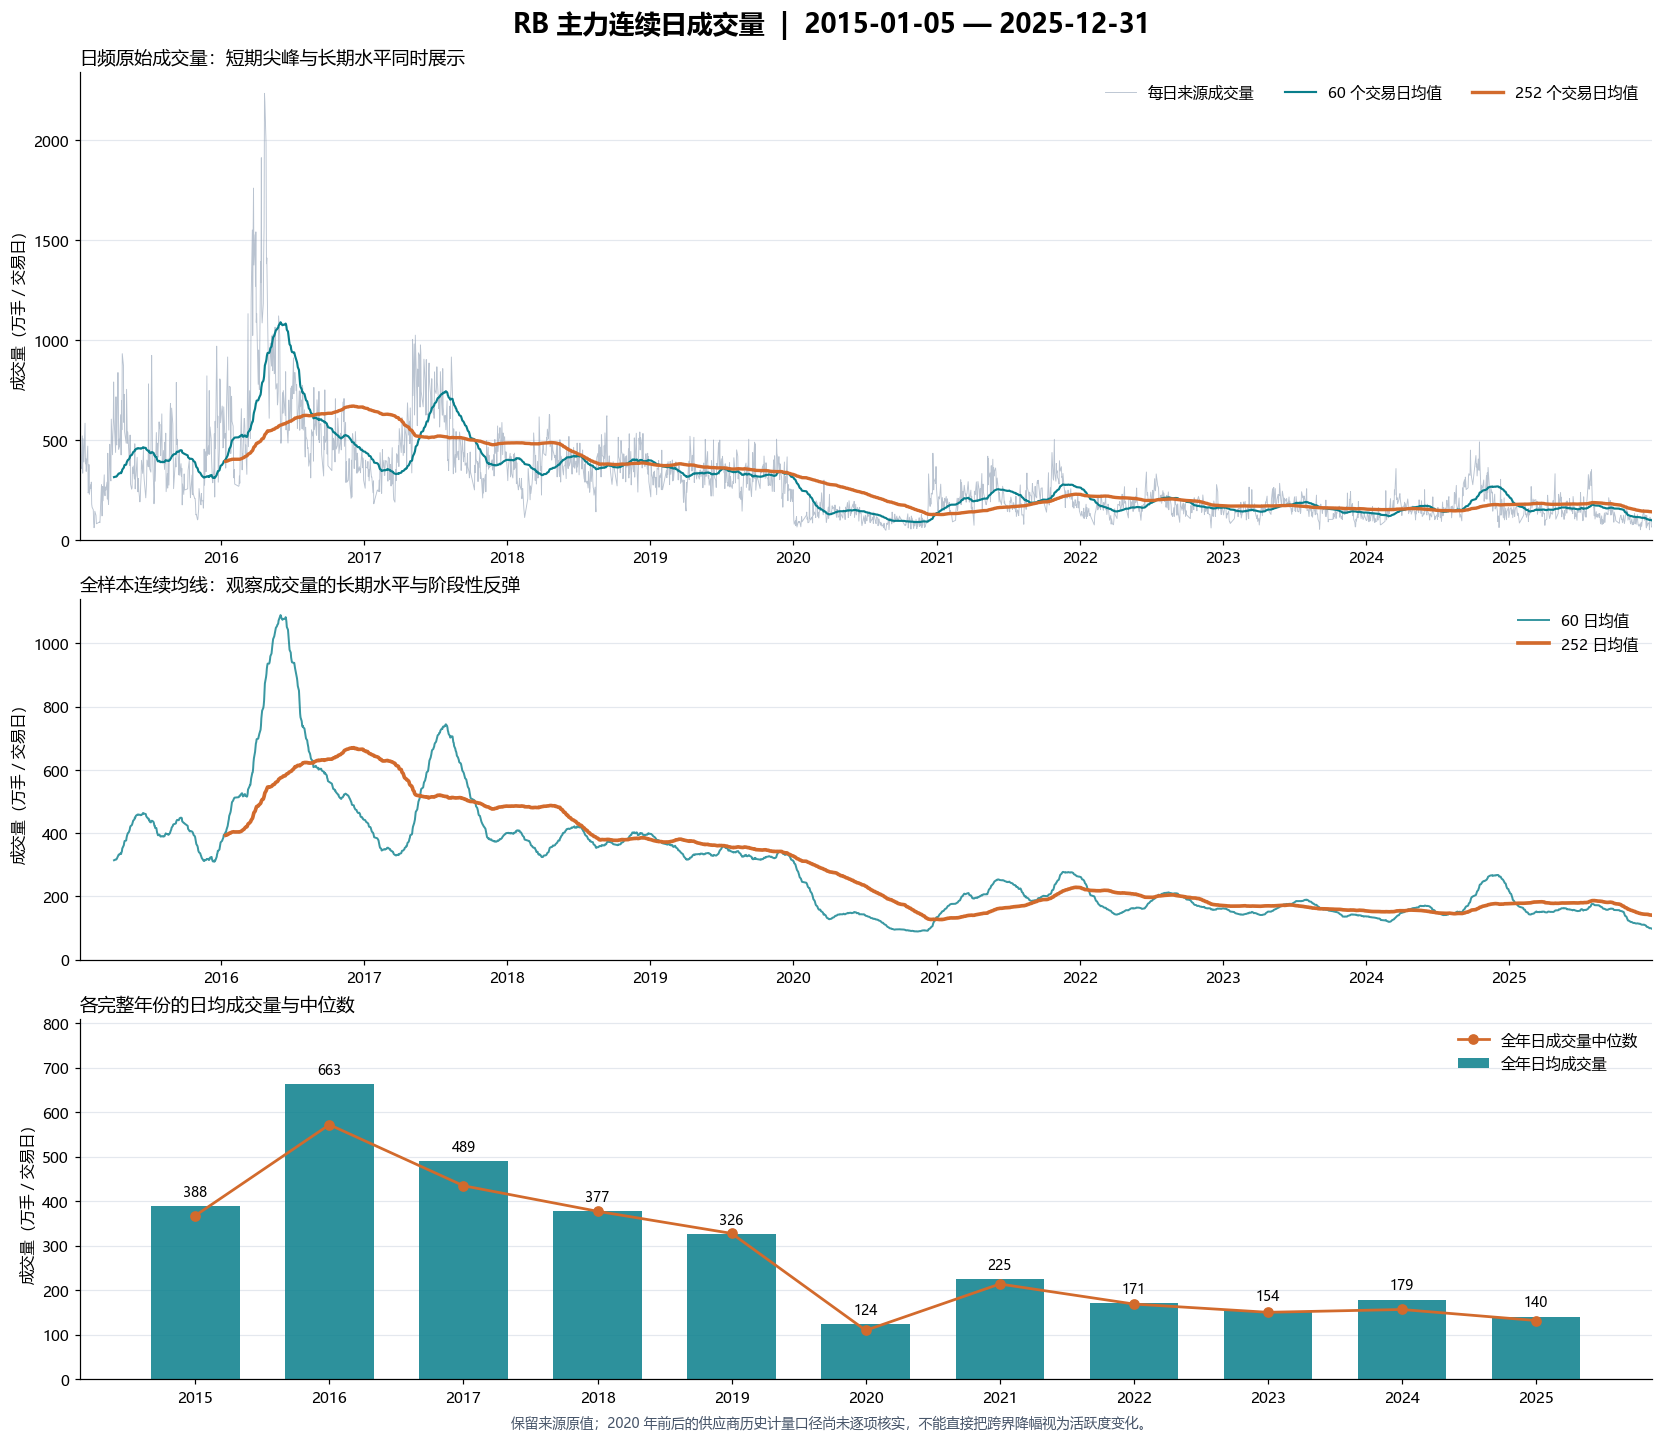

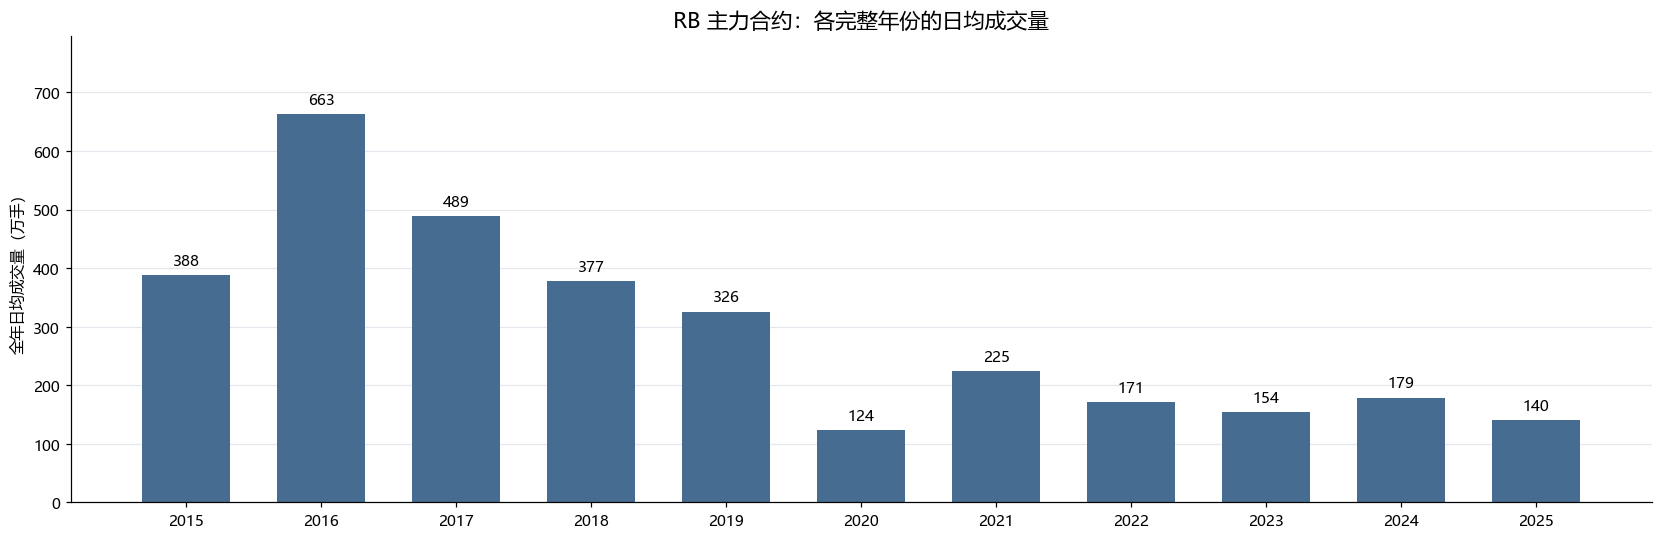

成交量趋势图：E:\Latitude_Analytics_v2\00_draft_collection_01\testing_12/testing_12_rb_daily_volume.png
全年日均成交量图：E:\Latitude_Analytics_v2\00_draft_collection_01\testing_12/testing_12_rb_annual_volume.png


In [6]:
volume_unit = 10000
plot_dates = main_daily_volume_df["trading_date"]
short_volume_ma = main_daily_volume_df[f"volume_ma_{SHORT_WINDOW}"] / volume_unit
long_volume_ma = main_daily_volume_df[f"volume_ma_{LONG_WINDOW}"] / volume_unit
fig, axes = plt.subplots(3, 1, figsize=(15, 13), layout="constrained", gridspec_kw={"height_ratios": [1.3, 1, 1]})
fig.suptitle(f"{underlying_code} 主力连续日成交量  |  {sample_start} — {sample_end}", fontsize=17, fontweight="bold")
axes[0].plot(plot_dates, main_daily_volume_df["volume"] / volume_unit, color="#94a3b8", lw=0.6, alpha=0.65, label="每日来源成交量")
axes[0].plot(plot_dates, short_volume_ma, color="#087e8b", lw=1.4, label=f"{SHORT_WINDOW} 个交易日均值")
axes[0].plot(plot_dates, long_volume_ma, color="#d26a2c", lw=2.2, label=f"{LONG_WINDOW} 个交易日均值")
axes[0].set_title("日频原始成交量：短期尖峰与长期水平同时展示", loc="left", fontsize=12)
axes[0].legend(loc="upper right", ncol=3, frameon=False)
axes[1].plot(plot_dates, short_volume_ma, color="#087e8b", lw=1.3, alpha=0.8, label=f"{SHORT_WINDOW} 日均值")
axes[1].plot(plot_dates, long_volume_ma, color="#d26a2c", lw=2.4, label=f"{LONG_WINDOW} 日均值")
axes[1].set_title("全样本连续均线：观察成交量的长期水平与阶段性反弹", loc="left", fontsize=12)
axes[1].legend(loc="upper right", frameon=False)
for axis in axes[:2]:
    axis.xaxis.set_major_locator(mdates.YearLocator())
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axis.set_xlim(plot_dates.min(), plot_dates.max())
    axis.set_ylabel("成交量（万手／交易日）")


years = annual_volume_df.index.to_numpy(dtype=int)
annual_bars = axes[2].bar(years, annual_volume_df["mean_volume"] / volume_unit, color="#087e8b", width=0.66, alpha=0.85, label="全年日均成交量")
axes[2].plot(years, annual_volume_df["median_volume"] / volume_unit, color="#d26a2c", marker="o", lw=1.8, label="全年日成交量中位数")
axes[2].bar_label(annual_bars, fmt="%.0f", fontsize=9, padding=4)
axes[2].set_xticks(years)
axes[2].set_ylabel("成交量（万手／交易日）")
axes[2].set_title("各完整年份的日均成交量与中位数", loc="left", fontsize=12)
axes[2].legend(loc="upper right", frameon=False)
axes[2].set_ylim(0, (annual_volume_df["mean_volume"] / volume_unit).max() * 1.22)
for axis in axes:
    axis.set_ylim(bottom=0)
    axis.grid(axis="y", color="#d6dde5", alpha=0.65)
    axis.set_axisbelow(True)
fig.supxlabel("保留来源原值；2020 年前后的供应商历史计量口径尚未逐项核实，不能直接把跨界降幅视为活跃度变化。", fontsize=9, color="#475569")
volume_figure_path = output_dir / "testing_12_rb_daily_volume.png"
if EXPORT_FILES:
    fig.savefig(volume_figure_path, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()


fig, axis = plt.subplots(figsize=(15, 4.8), layout="constrained")
annual_volume_bars = axis.bar(years, annual_volume_df["mean_volume"] / volume_unit, color="#476c91", width=0.65)
axis.bar_label(annual_volume_bars, fmt="%.0f", padding=4, fontsize=10)
axis.set_xticks(years)
axis.set_ylabel("全年日均成交量（万手）")
axis.set_ylim(0, (annual_volume_df["mean_volume"] / volume_unit).max() * 1.2)
axis.set_title(f"{underlying_code} 主力合约：各完整年份的日均成交量", fontsize=14)
axis.grid(axis="y", color="#d6dde5", alpha=0.65)
axis.set_axisbelow(True)
annual_volume_figure_path = output_dir / "testing_12_rb_annual_volume.png"
if EXPORT_FILES:
    fig.savefig(annual_volume_figure_path, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()
if EXPORT_FILES:
    print(f"成交量趋势图：{volume_figure_path}")
if EXPORT_FILES:
    print(f"全年日均成交量图：{annual_volume_figure_path}")

## 5. 完整年度的成交量变化

比较最新完整年份与上一年的全年日均成交量，并列出相对 2021 年全年日均成交量的变化。
这些是描述性比较；阶段性反弹可以与较长时期的下降同时存在，不进行统计显著性检验。


In [7]:
latest_year = int(annual_volume_df.index[-1])
latest_daily_mean = float(annual_volume_df.loc[latest_year, "mean_volume"])
print(f"{latest_year} 年全年日均成交量：{latest_daily_mean / 10000:.2f} 万手。")
if latest_year - 1 in annual_volume_df.index:
    previous_annual_mean = float(annual_volume_df.loc[latest_year - 1, "mean_volume"])
    print(f"{latest_year - 1} 年全年日均 {previous_annual_mean / 10000:.2f} 万手；同比 {(latest_daily_mean / previous_annual_mean - 1):+.1%}。")
if 2021 in annual_volume_df.index:
    reference_annual_mean = float(annual_volume_df.loc[2021, "mean_volume"])
    print(f"2021 年全年日均 {reference_annual_mean / 10000:.2f} 万手；{latest_year} 年较其变化 {(latest_daily_mean / reference_annual_mean - 1):+.1%}。")

2025 年全年日均成交量：140.24 万手。
2024 年全年日均 178.70 万手；同比 -21.5%。
2021 年全年日均 224.63 万手；2025 年较其变化 -37.6%。


## 6. 用分钟收益计算每日双幂变差（BV）

记 $\widetilde P_{d,i}$ 为复权收盘价，$p_{d,i}=\ln\widetilde P_{d,i}$ 为自然对数价格。
把每个交易日 $d$ 内已观测到的对数价格按时间排列为 $p_{d,0},\ldots,p_{d,n_d}$。
计算同一交易日内的相邻收益，然后对相邻绝对收益的乘积**求和**：

$$r_{d,i}=p_{d,i}-p_{d,i-1}=\ln\!\left(\frac{\widetilde P_{d,i}}{\widetilde P_{d,i-1}}\right),\qquad
BV_d=\frac{\pi}{2}\sum_{i=2}^{n_d}|r_{d,i-1}||r_{d,i}|.$$

本节采用上式原始形式，不额外乘有限样本修正项，不除以分钟数、不取平方根、不年化。
$(\pi/2)|r_{d,i-1}||r_{d,i}|$ 是分钟贡献项，$BV_d$ 才是每日双幂变差。
定义参考[美联储研究第 2.5 节对相邻绝对收益乘积求和的定义及有限样本修正说明](https://www.federalreserve.gov/pubs/ifdp/2007/905/revision/ifdp905r.htm)。

**观测与边界：**使用 `backward_adjusted_log_close`，按 `trading_date`（交易日）分组，包含归属该交易日的夜盘。
每个交易日重新计算收益和滞后收益，不跨交易日或主力换约配对。只有同日的收盘价被使用：第一根 bar 没有收益，
第二根 bar 有第一个收益，第三根 bar 开始产生第一个乘积。这里没有用上一交易日收盘价补出首个收益。

交易日内按相邻观测配对，不在午休或夜盘转日盘时重新起算；恢复交易后的价差计入下一观测收益。
休市或缺失分钟不插值，也不把其间变动误标为恰好一分钟的日历时长收益。因此，BV 覆盖的是快照实际观测的同日收盘价区间，
不是经完整分钟格点验收的全日估计。所有有效零收益和极端值均保留。

**趋势口径：**主图绘制 $BV_d$ 的日序列及其 60／252 个交易日均值，年度统计对 $BV_d$ 求日均和中位数。
BV 是每日累计量，交易时长和可用观测数不同会影响比较，表中列出有效收益数和配对数。
收益使用小数形式；为方便阅读，图表乘以 $10^8$ 显示为 **bp²**（1 bp = 0.0001），不改变计算口径。
成交量的 2020 年单双边计量边界不作用于收益和 BV，本节均线不在该日期重新起算。


In [8]:
rb_minute_bv_df = rb_main_minute_df[
    ["bar_at", "trading_date", "contract_code", "continuity_segment", "backward_adjusted_log_close"]
].sort_values("bar_at").reset_index(drop=True).copy()
rb_minute_bv_df["trading_date"] = pd.to_datetime(rb_minute_bv_df["trading_date"])
rb_minute_bv_df["backward_adjusted_log_close"] = rb_minute_bv_df["backward_adjusted_log_close"].astype("float64")

# 验证研究快照的配对前提，不对正式湖做全量复验。
if rb_minute_bv_df["bar_at"].duplicated().any():
    raise ValueError("主力分钟快照包含重复时间，无法唯一确定相邻观测。")
if rb_minute_bv_df.isna().any().any() or not np.isfinite(rb_minute_bv_df["backward_adjusted_log_close"]).all():
    raise ValueError("分钟收益的输入身份、时间或对数收盘价无效。")
daily_identity_counts_df = rb_minute_bv_df.groupby("trading_date")[["contract_code", "continuity_segment"]].nunique()
if daily_identity_counts_df.gt(1).any().any():
    raise ValueError("同一交易日包含多个真实合约或连续片段，不能直接计算日内 BV。")

# backward_adjusted_log_close 已是自然对数价格；差分得到 ln(P_t / P_{t-1})。
# 两次相邻操作都在交易日内完成，禁止上一交易日收益进入乘积。
rb_minute_bv_df["minute_log_return"] = rb_minute_bv_df.groupby("trading_date")["backward_adjusted_log_close"].diff()
rb_minute_bv_df["previous_minute_log_return"] = rb_minute_bv_df.groupby("trading_date")["minute_log_return"].shift(1)
rb_minute_bv_df["bv_contribution"] = (
    (np.pi / 2)
    * rb_minute_bv_df["previous_minute_log_return"].abs()
    * rb_minute_bv_df["minute_log_return"].abs()
)
valid_bv_pair_mask = rb_minute_bv_df["bv_contribution"].notna()
rb_minute_bv_df["zero_bv_pair"] = rb_minute_bv_df["bv_contribution"].eq(0) & valid_bv_pair_mask

daily_bv_df = rb_minute_bv_df.groupby("trading_date").agg(
    minute_rows=("bar_at", "size"),
    valid_returns=("minute_log_return", "count"),
    valid_pairs=("bv_contribution", "count"),
    zero_pairs=("zero_bv_pair", "sum"),
)
# 核心计算是 sum；min_count=1 防止没有有效收益对的交易日被当作零 BV。
daily_bv_df["bipower_variation"] = rb_minute_bv_df.groupby("trading_date")["bv_contribution"].sum(min_count=1)
daily_bv_df["zero_pair_share"] = daily_bv_df["zero_pairs"] / daily_bv_df["valid_pairs"].replace(0, np.nan)
if not daily_bv_df["valid_pairs"].eq((daily_bv_df["minute_rows"] - 2).clip(lower=0)).all():
    raise AssertionError("每个交易日应从第三个收盘价开始产生相邻收益乘积。")
if not np.isfinite(daily_bv_df["bipower_variation"].dropna()).all() or daily_bv_df["bipower_variation"].lt(0).any():
    raise ValueError("每日 BV 必须是有限非负数。")

# 与成交量章节的样本交易日对齐，无分钟输入的日期保留为空值。
daily_bv_df = daily_bv_df.reindex(pd.DatetimeIndex(main_daily_volume_df["trading_date"], name="trading_date"))
for window in [SHORT_WINDOW, LONG_WINDOW]:
    daily_bv_df[f"bv_ma_{window}"] = daily_bv_df["bipower_variation"].rolling(window, min_periods=window).mean()

print(f"分钟记录 {len(rb_minute_bv_df):,}；有效同日相邻收益 {rb_minute_bv_df['minute_log_return'].notna().sum():,}；有效相邻收益对 {valid_bv_pair_mask.sum():,}")
print(f"有效日 BV {daily_bv_df['bipower_variation'].notna().sum():,}；缺失日 BV {daily_bv_df['bipower_variation'].isna().sum():,}")
display(rb_minute_bv_df[["bar_at", "minute_log_return", "previous_minute_log_return", "bv_contribution"]].head(6))
display(daily_bv_df.tail())

分钟记录 943,770；有效同日相邻收益 941,096；有效相邻收益对 938,422
有效日 BV 2,674；缺失日 BV 0


,bar_at,minute_log_return,previous_minute_log_return,bv_contribution
0,2015-01-05 09:01:00+08:00,NaN,NaN,NaN
1,2015-01-05 09:02:00+08:00,0.001174,NaN,NaN
2,2015-01-05 09:03:00+08:00,0.000000,0.001174,0.000000
3,2015-01-05 09:04:00+08:00,0.000782,0.000000,0.000000
4,2015-01-05 09:05:00+08:00,-0.001173,0.000782,0.000001
5,2015-01-05 09:06:00+08:00,0.001954,-0.001173,0.000004


,minute_rows,valid_returns,valid_pairs,zero_pairs,bipower_variation,zero_pair_share,bv_ma_60,bv_ma_252
trading_date,,,,,,,,
2025-12-25,345,344,343,214,0.000039,0.623907,0.000057,0.00008
2025-12-26,345,344,343,172,0.000068,0.501458,0.000057,0.00008
2025-12-29,345,344,343,163,0.000078,0.475219,0.000058,0.00008
2025-12-30,345,344,343,186,0.000051,0.542274,0.000057,0.00008
2025-12-31,345,344,343,204,0.000047,0.594752,0.000057,0.00008


## 7. 每日 BV 的完整年度统计

每个年份使用该年全部交易日的每日 BV 求均值和中位数。每日 BV 仍是相邻绝对收益乘积之和，没有除以分钟配对数。
“零乘积占比”是有效贡献项中零值的比例，不是缺失比例。


In [9]:
annual_bv_df = daily_bv_df.groupby(daily_bv_df.index.year).agg(
    valid_days=("bipower_variation", "count"),
    mean_bv=("bipower_variation", "mean"),
    median_bv=("bipower_variation", "median"),
    mean_returns_per_day=("valid_returns", "mean"),
    mean_pairs_per_day=("valid_pairs", "mean"),
    valid_pairs=("valid_pairs", "sum"),
    zero_pairs=("zero_pairs", "sum"),
)
annual_bv_df.index.name = "year"
annual_bv_df["zero_pair_share"] = annual_bv_df["zero_pairs"] / annual_bv_df["valid_pairs"].replace(0, np.nan)

bv_end_date = daily_bv_df.index.max()
annual_bv_df["change_pct"] = annual_bv_df["mean_bv"].pct_change(fill_method=None) * 100
annual_bv_display_df = pd.DataFrame({
    "有效交易日": annual_bv_df["valid_days"],
    "日均有效收益数": annual_bv_df["mean_returns_per_day"],
    "日均配对数": annual_bv_df["mean_pairs_per_day"],
    "全年平均日BV（bp²）": annual_bv_df["mean_bv"] * 1e8,
    "全年日BV中位数（bp²）": annual_bv_df["median_bv"] * 1e8,
    "零贡献占比（%）": annual_bv_df["zero_pair_share"] * 100,
    "平均日BV同比（%）": annual_bv_df["change_pct"],
})
display(annual_bv_display_df.round(3))


,有效交易日,日均有效收益数,日均配对数,全年平均日BV（bp²）,全年日BV中位数（bp²）,零贡献占比（%）,平均日BV同比（%）
year,,,,,,,
2015,244,456.131,455.131,15433.179,11690.845,60.969,NaN
2016,244,377.934,376.934,50957.360,40940.041,36.486,230.181
2017,244,341.049,340.049,37127.812,35946.465,23.869,-27.139
2018,243,340.543,339.543,16790.839,14719.733,31.371,-54.776
2019,244,340.557,339.557,13381.610,12476.692,34.933,-20.304
2020,243,310.914,309.914,12163.013,9089.347,39.212,-9.107
2021,243,340.543,339.543,34933.833,27309.951,18.971,187.214
2022,242,340.529,339.529,22489.525,19092.819,24.721,-35.623
2023,242,341.025,340.025,12214.389,11191.482,34.410,-45.689


## 8. 每日双幂变差的变化趋势

第一幅保留全部日 BV 波动，并叠加 60／252 日均线。第二幅单独展示均线，使长期水平不被单日尖峰遮住。
第三幅比较各完整年份的平均日 BV。三幅都采用从零开始的线性纵轴。

图形展示由分钟收益估计的每日累计变差，不是分钟贡献项的平均值。交易时长、数据覆盖、零收益比例等也可能影响其水平；
仅凭曲线不能判断下降原因，也不能将肉眼可见趋势直接称为统计显著。


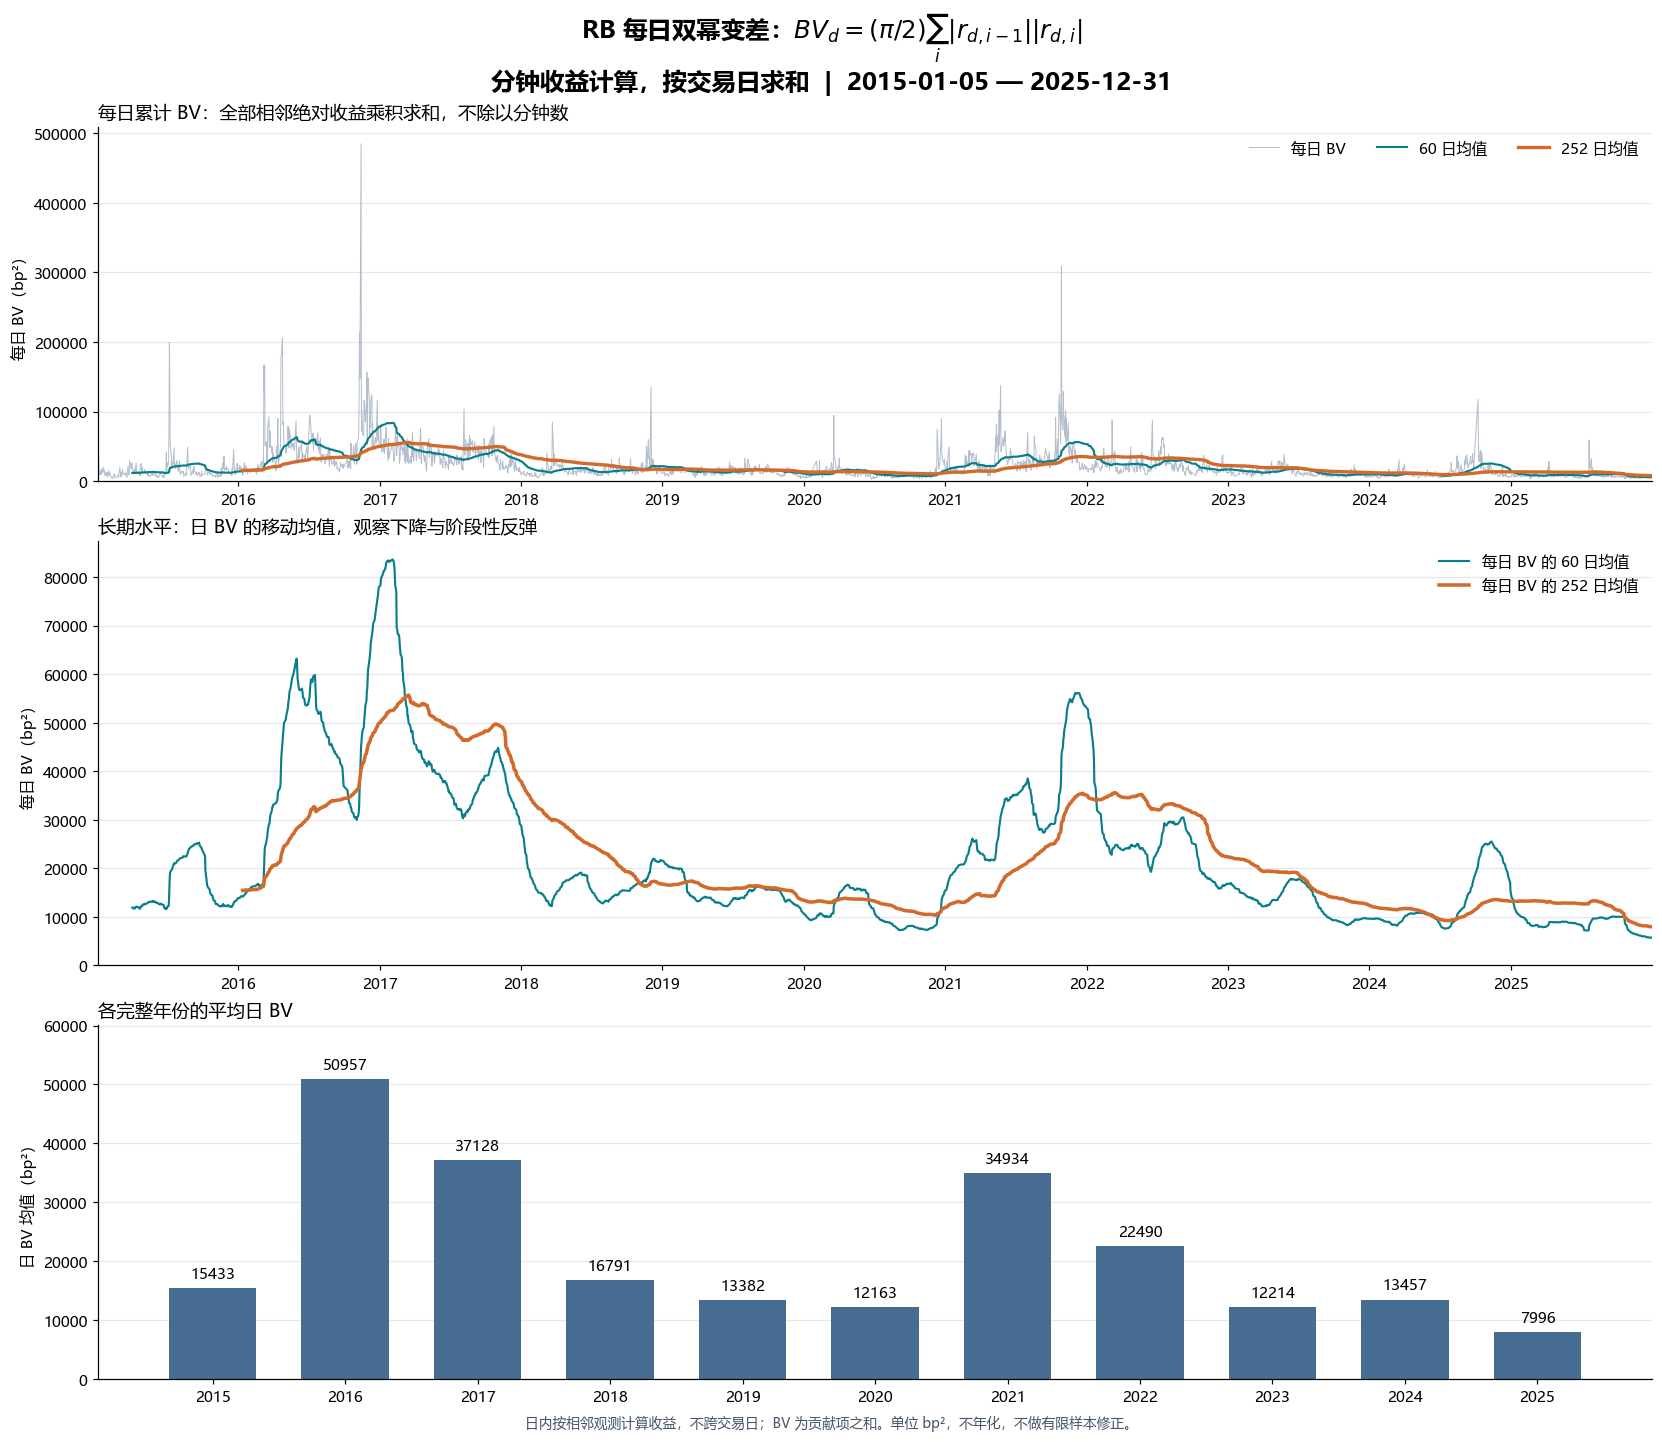

2025 年全年平均日 BV = 7.9963029e-05（小数收益平方）= 7996.303 bp²。
2024 年全年平均日 BV = 13457.060 bp²；同比 -40.6%。
图片：E:\Latitude_Analytics_v2\00_draft_collection_01\testing_12/testing_12_rb_daily_bipower_variation.png


In [10]:
bv_scale = 1e8
fig, axes = plt.subplots(3, 1, figsize=(15, 13), layout="constrained", gridspec_kw={"height_ratios": [1, 1.2, 1]})
fig.suptitle(
    r"RB 每日双幂变差：$BV_d=(\pi/2)\sum_i |r_{d,i-1}||r_{d,i}|$"
    + f"\n分钟收益计算，按交易日求和  |  {daily_bv_df.index.min():%Y-%m-%d} — {bv_end_date:%Y-%m-%d}",
    fontsize=16, fontweight="bold",
)
axes[0].plot(daily_bv_df.index, daily_bv_df["bipower_variation"] * bv_scale, color="#94a3b8", lw=0.65, alpha=0.7, label="每日 BV")
axes[0].plot(daily_bv_df.index, daily_bv_df[f"bv_ma_{SHORT_WINDOW}"] * bv_scale, color="#087e8b", lw=1.4, label=f"{SHORT_WINDOW} 日均值")
axes[0].plot(daily_bv_df.index, daily_bv_df[f"bv_ma_{LONG_WINDOW}"] * bv_scale, color="#d26a2c", lw=2.2, label=f"{LONG_WINDOW} 日均值")
axes[0].set_title("每日累计 BV：全部相邻绝对收益乘积求和，不除以分钟数", loc="left", fontsize=12)
axes[0].legend(loc="upper right", ncol=3, frameon=False)
axes[1].plot(daily_bv_df.index, daily_bv_df[f"bv_ma_{SHORT_WINDOW}"] * bv_scale, color="#087e8b", lw=1.4, label=f"每日 BV 的 {SHORT_WINDOW} 日均值")
axes[1].plot(daily_bv_df.index, daily_bv_df[f"bv_ma_{LONG_WINDOW}"] * bv_scale, color="#d26a2c", lw=2.3, label=f"每日 BV 的 {LONG_WINDOW} 日均值")
axes[1].set_title("长期水平：日 BV 的移动均值，观察下降与阶段性反弹", loc="left", fontsize=12)
axes[1].legend(loc="upper right", frameon=False)
for axis in axes[:2]:
    axis.set_ylabel("每日 BV（bp²）")
    axis.xaxis.set_major_locator(mdates.YearLocator())
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axis.set_xlim(daily_bv_df.index.min(), bv_end_date)

bv_years = annual_bv_df.index.to_numpy(dtype=int)
bv_bars = axes[2].bar(bv_years, annual_bv_df["mean_bv"] * bv_scale, width=0.66, color="#476c91")
axes[2].bar_label(bv_bars, fmt="%.0f", padding=4, fontsize=10)
axes[2].set_xticks(bv_years)
axes[2].set_ylim(0, (annual_bv_df["mean_bv"] * bv_scale).max() * 1.18)
axes[2].set_ylabel("日 BV 均值（bp²）")
axes[2].set_title("各完整年份的平均日 BV", loc="left", fontsize=12)
for axis in axes:
    axis.set_ylim(bottom=0)
    axis.ticklabel_format(axis="y", style="plain", useOffset=False)
    axis.grid(axis="y", alpha=0.65, color="#d6dde5")
    axis.set_axisbelow(True)
fig.supxlabel("日内按相邻观测计算收益，不跨交易日；BV 为贡献项之和。单位 bp²，不年化，不做有限样本修正。", fontsize=9, color="#475569")
bv_figure_path = output_dir / "testing_12_rb_daily_bipower_variation.png"
if EXPORT_FILES:
    fig.savefig(bv_figure_path, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()


latest_bv_year = int(annual_bv_df.index[-1])
latest_bv_mean = float(annual_bv_df.loc[latest_bv_year, "mean_bv"])
print(f"{latest_bv_year} 年全年平均日 BV = {latest_bv_mean:.8g}（小数收益平方）= {latest_bv_mean * bv_scale:.3f} bp²。")
if latest_bv_year - 1 in annual_bv_df.index:
    previous_bv_mean = float(annual_bv_df.loc[latest_bv_year - 1, "mean_bv"])
    print(f"{latest_bv_year - 1} 年全年平均日 BV = {previous_bv_mean * bv_scale:.3f} bp²；同比 {(latest_bv_mean / previous_bv_mean - 1):+.1%}。")
if EXPORT_FILES:
    print(f"图片：{bv_figure_path}")


## 9. RB 全合约收盘持仓量与日成交量

输入为第 2 节已读取的正式日线 `rb_daily_df`。按同一交易日、同一交易所和品种，分别加总全部真实合约的 `open_interest` 与 `volume`：

- `open_interest` 是每个合约的当日收盘持仓量，加总后得到该品种的全合约收盘持仓量。
- `volume` 是每个合约的当日成交量，加总后得到该品种的全合约日成交量。

两项均以手为单位，不把虚拟主力连续代码再加进总量。没有行情的记录保持缺失；若某个标记有行情的合约缺少持仓量或成交量，相应指标的当日总量保持缺失，避免不完整加总被误当作总量。

全合约成交量包含旧主力、新主力及其他月份，可以消除“只选择一个合约”带来的身份切换项；实际移仓交易和市场活跃度仍会改变总量。合约数及有效记录数用于说明参与加总的输入。

持仓量和成交量均使用来源原值，按全样本连续计算 60／252 个交易日移动均值。年度统计分别对每日收盘持仓量与每日成交量求均值；年度持仓均值不是把每日持仓相加的累计量。


In [11]:
variety_contract_daily_df = rb_daily_df[
    ["trading_date", "contract_code", "volume", "open_interest", "has_market_data"]
].copy()
variety_contract_daily_df["trading_date"] = pd.to_datetime(variety_contract_daily_df["trading_date"])
variety_contract_daily_df["missing_market_volume"] = (
    variety_contract_daily_df["has_market_data"].fillna(False)
    & variety_contract_daily_df["volume"].isna()
)
variety_contract_daily_df["volume"] = variety_contract_daily_df["volume"].astype("float64").where(
    variety_contract_daily_df["has_market_data"].fillna(False)
)
variety_contract_daily_df["missing_market_open_interest"] = (
    variety_contract_daily_df["has_market_data"].fillna(False)
    & variety_contract_daily_df["open_interest"].isna()
)
variety_contract_daily_df["open_interest"] = variety_contract_daily_df["open_interest"].astype("float64").where(
    variety_contract_daily_df["has_market_data"].fillna(False)
)
variety_daily_volume_df = variety_contract_daily_df.groupby("trading_date").agg(
    reported_contracts=("contract_code", "size"),
    contracts_with_volume=("volume", "count"),
    missing_market_volume_count=("missing_market_volume", "sum"),
)
variety_daily_volume_df["total_volume"] = (
    variety_contract_daily_df.groupby("trading_date")["volume"].sum(min_count=1)
    .where(variety_daily_volume_df["missing_market_volume_count"].eq(0))
)
variety_daily_volume_df = variety_daily_volume_df.reindex(
    pd.DatetimeIndex(main_daily_volume_df["trading_date"], name="trading_date")
)
for window in [SHORT_WINDOW, LONG_WINDOW]:
    variety_daily_volume_df[f"total_volume_ma_{window}"] = (
        variety_daily_volume_df["total_volume"].rolling(window, min_periods=window).mean()
    )
main_volume_by_date = main_daily_volume_df.set_index("trading_date")["volume"]
if (variety_daily_volume_df["total_volume"] + 1e-8 < main_volume_by_date).any():
    raise AssertionError("全部合约成交量应不小于其中的主力合约成交量。")

annual_variety_volume_df = variety_daily_volume_df.groupby(variety_daily_volume_df.index.year).agg(
    valid_days=("total_volume", "count"), mean_volume=("total_volume", "mean"),
    median_volume=("total_volume", "median"), mean_contracts=("contracts_with_volume", "mean"),
)
annual_variety_volume_df.index.name = "year"

variety_daily_open_interest_df = variety_contract_daily_df.groupby("trading_date").agg(
    reported_contracts=("contract_code", "size"),
    contracts_with_open_interest=("open_interest", "count"),
    missing_market_open_interest_count=("missing_market_open_interest", "sum"),
)
variety_daily_open_interest_df["total_open_interest"] = (
    variety_contract_daily_df.groupby("trading_date")["open_interest"].sum(min_count=1)
    .where(variety_daily_open_interest_df["missing_market_open_interest_count"].eq(0))
)
variety_daily_open_interest_df = variety_daily_open_interest_df.reindex(
    pd.DatetimeIndex(main_daily_volume_df["trading_date"], name="trading_date")
)
for window in [SHORT_WINDOW, LONG_WINDOW]:
    variety_daily_open_interest_df[f"total_open_interest_ma_{window}"] = (
        variety_daily_open_interest_df["total_open_interest"].rolling(window, min_periods=window).mean()
    )
annual_variety_open_interest_df = variety_daily_open_interest_df.groupby(variety_daily_open_interest_df.index.year).agg(
    valid_days=("total_open_interest", "count"),
    mean_open_interest=("total_open_interest", "mean"),
    median_open_interest=("total_open_interest", "median"),
)
annual_variety_open_interest_df.index.name = "year"

print(f"合约日线记录 {len(variety_contract_daily_df):,}；样本涉及真实合约 {variety_contract_daily_df['contract_code'].nunique():,} 个。")
print(f"有效全合约持仓量交易日 {variety_daily_open_interest_df['total_open_interest'].notna().sum():,}；有效全合约成交量交易日 {variety_daily_volume_df['total_volume'].notna().sum():,}。")
display(pd.DataFrame({
    "持仓量有效交易日": annual_variety_open_interest_df["valid_days"],
    "成交量有效交易日": annual_variety_volume_df["valid_days"],
    "全合约全年日均收盘持仓（万手）": annual_variety_open_interest_df["mean_open_interest"] / 10000,
    "全合约全年日均成交量（万手）": annual_variety_volume_df["mean_volume"] / 10000,
}).round(2))


合约日线记录 32,085；样本涉及真实合约 144 个。
有效全合约持仓量交易日 2,674；有效全合约成交量交易日 2,674。


,持仓量有效交易日,成交量有效交易日,全合约全年日均收盘持仓（万手）,全合约全年日均成交量（万手）
year,,,,
2015,244,244,334.47,443.47
2016,244,244,337.26,765.70
2017,244,244,403.40,575.43
2018,243,243,353.49,437.02
2019,244,244,368.77,381.29
2020,243,243,190.30,150.64
2021,243,243,194.58,269.95
2022,242,242,273.38,217.02
2023,242,242,307.80,207.44


## 10. 全合约持仓量、成交量与主力每日 BV

大图使用 2015—2025 年数据，三行从上到下依次为：

1. **RB 全合约收盘持仓量**：同一交易日各真实合约 `open_interest` 之和。
2. **RB 全合约日成交量**：同一交易日各真实合约 `volume` 之和。
3. **RB 主力序列每日双幂变差 BV**：按第 6 节定义，由主力分钟对数收益的相邻绝对乘积逐日求和。

左列展示日频数据与 60／252 个交易日移动平均线；右列每根柱表示该年全部交易日的平均值。持仓量柱状图是全年日均收盘持仓量，成交量柱状图是全年日均成交量，BV 柱状图是全年平均日 BV。

六个面板共享日期轴，年度柱位于各年份年中以对齐年份。三个指标分别使用适合其量级的纵轴，均从零开始；持仓量和成交量单位为万手，BV 单位为 bp²。曲线及均线全程连续绘制。


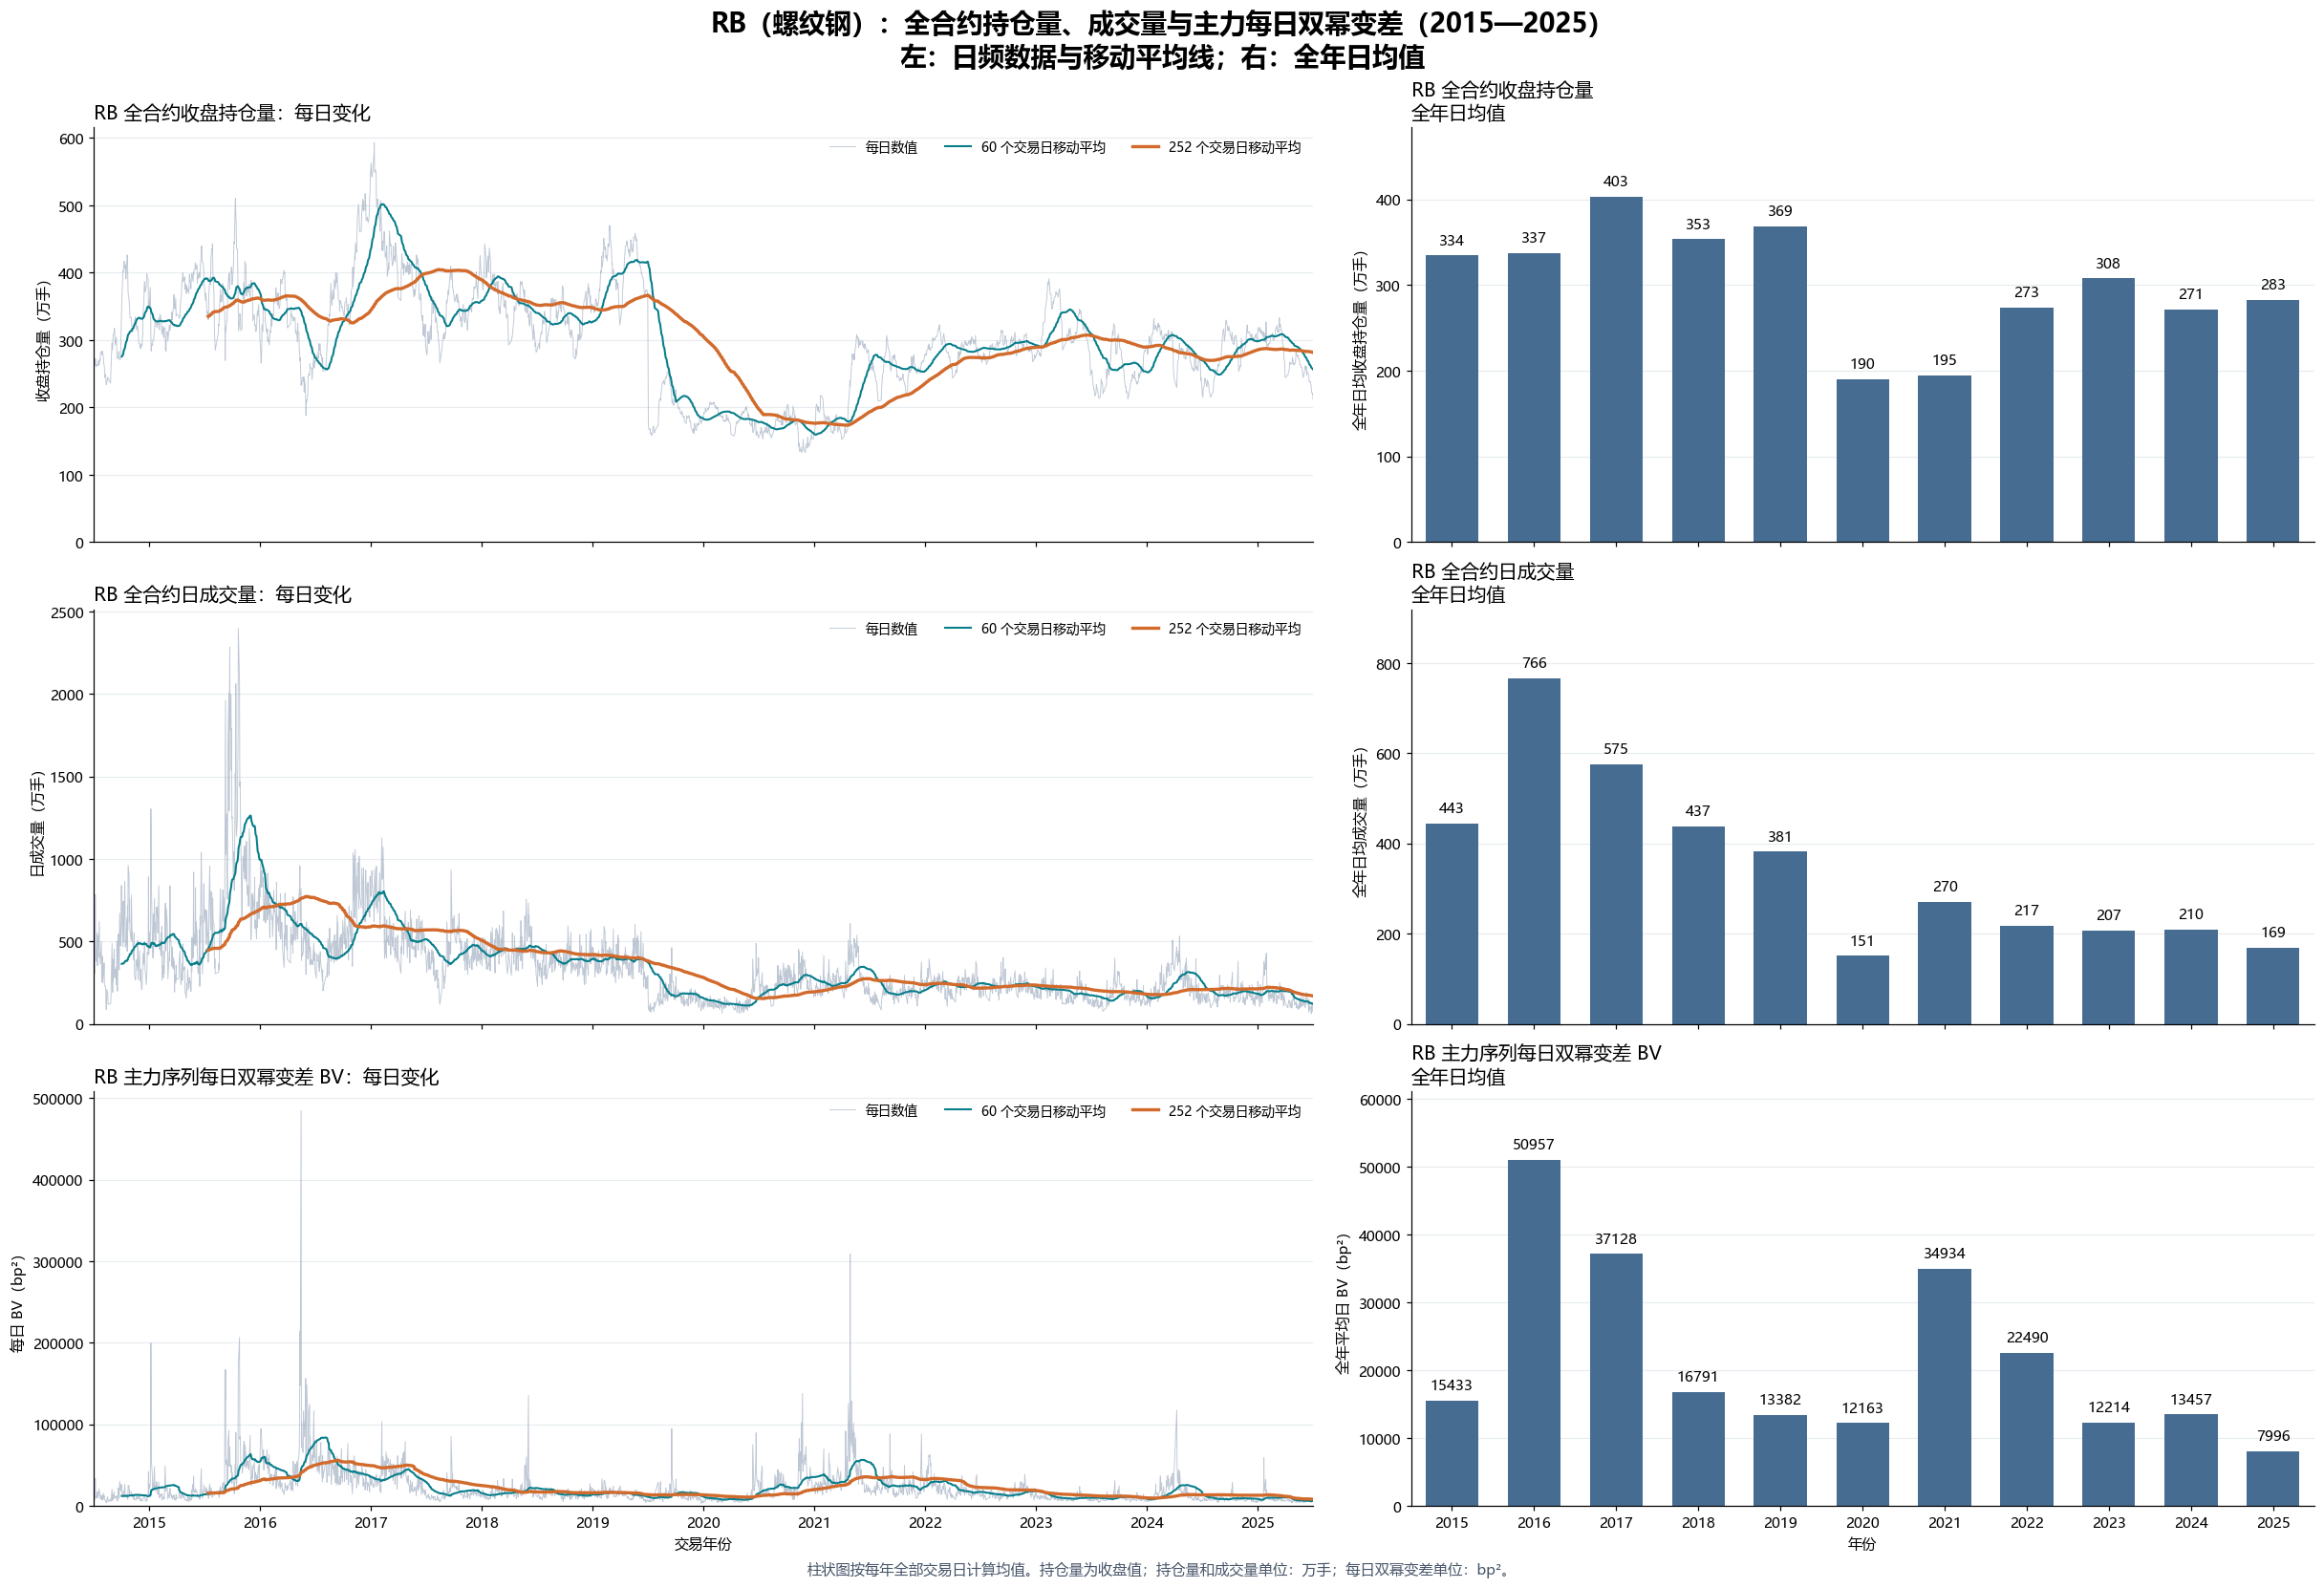

六面板共享 x 轴合图：E:\Latitude_Analytics_v2\00_draft_collection_01\testing_12/testing_12_rb_volume_bv_shared_x.png


In [12]:
open_interest_volume_bv_daily_df = (
    variety_daily_open_interest_df[
        ["total_open_interest", f"total_open_interest_ma_{SHORT_WINDOW}", f"total_open_interest_ma_{LONG_WINDOW}"]
    ]
    .join(variety_daily_volume_df[["total_volume", f"total_volume_ma_{SHORT_WINDOW}", f"total_volume_ma_{LONG_WINDOW}"]], how="outer", validate="one_to_one")
    .join(daily_bv_df[["bipower_variation", f"bv_ma_{SHORT_WINDOW}", f"bv_ma_{LONG_WINDOW}"]], how="outer", validate="one_to_one")
    .sort_index()
)
open_interest_volume_bv_figure, open_interest_volume_bv_axes = plt.subplots(
    3, 2, figsize=(22, 15), sharex=True, layout="constrained",
    gridspec_kw={"width_ratios": [1.35, 1]},
)

open_interest_volume_bv_figure.suptitle(
    f"RB（螺纹钢）：全合约持仓量、成交量与主力每日双幂变差（{sample_start.year}—{sample_end.year}）" + chr(10)
    + "左：日频数据与移动平均线；右：全年日均值",
    fontsize=18, fontweight="bold",
)
plot_years = annual_variety_open_interest_df.index.to_numpy(dtype=int)
annual_bar_centers = pd.to_datetime([f"{year}-07-01" for year in plot_years])
plot_start = pd.Timestamp(year=int(plot_years.min()), month=1, day=1)
plot_end = pd.Timestamp(year=int(plot_years.max()), month=12, day=31)

# 每根柱使用该年全部交易日的平均值。
combined_plot_rows = [
    ("RB 全合约收盘持仓量", "total_open_interest", "total_open_interest_ma", 1 / 10000, "收盘持仓量（万手）", "全年日均收盘持仓量（万手）", annual_variety_open_interest_df["mean_open_interest"]),
    ("RB 全合约日成交量", "total_volume", "total_volume_ma", 1 / 10000, "日成交量（万手）", "全年日均成交量（万手）", annual_variety_volume_df["mean_volume"]),
    ("RB 主力序列每日双幂变差 BV", "bipower_variation", "bv_ma", 1e8, "每日 BV（bp²）", "全年平均日 BV（bp²）", annual_bv_df["mean_bv"]),
]
for row_index, (title, daily_column, moving_prefix, scale, daily_unit, mean_unit, annual_mean) in enumerate(combined_plot_rows):
    daily_axis, annual_axis = open_interest_volume_bv_axes[row_index]
    daily_axis.plot(open_interest_volume_bv_daily_df.index, open_interest_volume_bv_daily_df[daily_column] * scale, color="#94a3b8", lw=0.6, alpha=0.6, label="每日数值")
    daily_axis.plot(open_interest_volume_bv_daily_df.index, open_interest_volume_bv_daily_df[f"{moving_prefix}_{SHORT_WINDOW}"] * scale, color="#087e8b", lw=1.35, label=f"{SHORT_WINDOW} 个交易日移动平均")
    daily_axis.plot(open_interest_volume_bv_daily_df.index, open_interest_volume_bv_daily_df[f"{moving_prefix}_{LONG_WINDOW}"] * scale, color="#d26a2c", lw=2.2, label=f"{LONG_WINDOW} 个交易日移动平均")
    daily_axis.set_title(title + "：每日变化", loc="left", fontsize=13)
    daily_axis.legend(loc="upper right", frameon=False, ncol=3, fontsize=9)
    daily_axis.set_ylabel(daily_unit)

    annual_bars = annual_axis.bar(
        annual_bar_centers, annual_mean.reindex(plot_years) * scale,
        width=235, color="#476c91",
    )
    annual_axis.bar_label(annual_bars, fmt="%.0f", fontsize=10, padding=5)
    annual_axis.set_title(title + chr(10) + "全年日均值", loc="left", fontsize=13)
    annual_axis.set_ylabel(mean_unit)
    annual_axis.set_ylim(0, annual_mean.max() * scale * 1.2)
    for axis in (daily_axis, annual_axis):
        axis.set_ylim(bottom=0)
        axis.grid(axis="y", color="#d6dde5", alpha=0.55)
        axis.set_axisbelow(True)
        axis.ticklabel_format(axis="y", style="plain", useOffset=False)

open_interest_volume_bv_axes[-1, 0].xaxis.set_major_locator(mdates.YearLocator(month=7, day=1))
open_interest_volume_bv_axes[-1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
open_interest_volume_bv_axes[-1, 0].set_xlim(plot_start, plot_end)
open_interest_volume_bv_axes[-1, 0].set_xlabel("交易年份")
open_interest_volume_bv_axes[-1, 1].set_xlabel("年份")
open_interest_volume_bv_figure.supxlabel(
    "柱状图按每年全部交易日计算均值。持仓量为收盘值；持仓量和成交量单位：万手；每日双幂变差单位：bp²。",
    fontsize=10, color="#475569",
)
open_interest_volume_bv_figure_path = output_dir / "testing_12_rb_volume_bv_shared_x.png"
if EXPORT_FILES:
    open_interest_volume_bv_figure.savefig(open_interest_volume_bv_figure_path, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()
if EXPORT_FILES:
    print(f"六面板共享 x 轴合图：{open_interest_volume_bv_figure_path}")

## 11. 全部合约加总是否减轻换约附近的跳变？

将当日主力代码与上一交易日比较，代码改变的日期记为“主力切换日”；这不是所有市场参与者开始或结束移仓的日期。
比较主力成交量和全合约总量的 **绝对日变动率 = |V(d) / V(d−1) − 1| × 100%**，避免直接比较不同量级的绝对手数。
另展示主力切换日前后各两个交易日的窗口，以及窗口外的日期。前值为零、缺失或非有限时不计算变动率；
两个序列使用共同有效的比较日期。

“更平稳”在这里仅指日变动率更小，不等于去除了噪音、通过平稳性检验或没有真实成交冲击。
加总无需选择主力身份，因此不会因替换被选合约本身而跳变；但实际移仓交易、市场事件、缺失数据和历史统计口径变化仍可能影响总量。


In [13]:
roll_volume_comparison_df = (
    main_daily_volume_df.set_index("trading_date")[["contract_code", "volume"]]
    .rename(columns={"volume": "main_volume"})
    .join(variety_daily_volume_df[["total_volume"]], how="left", validate="one_to_one")
)
previous_main_contract = roll_volume_comparison_df["contract_code"].shift(1)
roll_volume_comparison_df["is_roll_day"] = (
    roll_volume_comparison_df["contract_code"].ne(previous_main_contract)
    & roll_volume_comparison_df["contract_code"].notna()
    & previous_main_contract.notna()
).fillna(False)
roll_nearby_mask = roll_volume_comparison_df["is_roll_day"].rolling(5, center=True, min_periods=1).max().astype(bool)
previous_volumes_df = roll_volume_comparison_df[["main_volume", "total_volume"]].shift(1)
absolute_volume_change_df = (
    (roll_volume_comparison_df[["main_volume", "total_volume"]] / previous_volumes_df.where(previous_volumes_df > 0) - 1).abs() * 100
).replace([np.inf, -np.inf], np.nan)
common_change_mask = absolute_volume_change_df.notna().all(axis=1)
roll_comparison_rows = []
for scope, scope_mask in [
    ("全部可比较交易日", pd.Series(True, index=roll_volume_comparison_df.index)),
    ("主力切换当日", roll_volume_comparison_df["is_roll_day"]),
    ("切换日前后各2个交易日", roll_nearby_mask),
    ("切换窗口以外", ~roll_nearby_mask),
]:
    scoped_volume_change_df = absolute_volume_change_df.loc[scope_mask & common_change_mask]
    roll_comparison_rows.append({
        "范围": scope, "比较天数": len(scoped_volume_change_df),
        "主力绝对日变动中位数（%）": scoped_volume_change_df["main_volume"].median(),
        "全合约绝对日变动中位数（%）": scoped_volume_change_df["total_volume"].median(),
        "主力绝对日变动90分位（%）": scoped_volume_change_df["main_volume"].quantile(0.9),
        "全合约绝对日变动90分位（%）": scoped_volume_change_df["total_volume"].quantile(0.9),
    })
roll_volume_summary_df = pd.DataFrame(roll_comparison_rows).set_index("范围")
print(f"观察到 {roll_volume_comparison_df['is_roll_day'].sum()} 个主力切换日。")
display(roll_volume_summary_df.round(2))
latest_variety_year = int(annual_variety_volume_df.index.max())
if latest_variety_year - 1 in annual_variety_volume_df.index:
    previous_total_mean = float(annual_variety_volume_df.loc[latest_variety_year - 1, "mean_volume"])
    latest_total_mean = float(annual_variety_volume_df.loc[latest_variety_year, "mean_volume"])
    print(f"RB 全部合约全年日均成交量：{latest_variety_year - 1} 年 {previous_total_mean / 10000:.2f} 万手，{latest_variety_year} 年 {latest_total_mean / 10000:.2f} 万手，同比 {(latest_total_mean / previous_total_mean - 1):+.1%}。")

观察到 33 个主力切换日。


,比较天数,主力绝对日变动中位数（%）,全合约绝对日变动中位数（%）,主力绝对日变动90分位（%）,全合约绝对日变动90分位（%）
范围,,,,,
全部可比较交易日,2673,17.55,17.00,46.03,44.30
主力切换当日,33,58.85,15.98,115.98,36.45
切换日前后各2个交易日,165,25.23,16.68,75.27,47.17
切换窗口以外,2508,17.19,17.02,44.33,44.16


RB 全部合约全年日均成交量：2024 年 209.56 万手，2025 年 169.31 万手，同比 -19.2%。


## 12. 分钟成交量与双幂变差分钟贡献项的对数联合分布

样本为 **2015—2025 年**，每个点对应同一交易日内的分钟 $t$。使用主力分钟对数收益，计算

$$r_{d,t}=\ln(\widetilde P_{d,t}/\widetilde P_{d,t-1}),\qquad
b_{d,t}=\frac{\pi}{2}|r_{d,t-1}||r_{d,t}|,\qquad
X_{d,t}=\ln(V_{d,t}/1\text{ 手}),\quad Y_{d,t}=\ln b_{d,t}.$$

$b_{d,t}$ 是 **双幂变差的分钟贡献项**；第 6 节的每日 $BV_d$ 是贡献项逐日求和。本节将分钟成交量与同一分钟结束时的贡献项配对，直接比较分钟观测。
两组横轴分别使用主力真实合约的本分钟成交量、RB 全部真实合约在同一分钟的成交量之和；两组纵轴都使用主力价格收益构造的 $b_{d,t}$。

收益和滞后收益均在同一个 `trading_date` 内计算，并要求 $t-2$、$t-1$、$t$ 是连续三个一分钟收盘时刻。跨休市、跨交易日或缺失分钟形成的间隔不进入本节分布。第 6 节每日 BV 的计算保持其已说明的观测区间定义。

主力分钟成交量来自 `testing_10/testing_10_rb_main_minute.parquet` 的 `volume`，单位为手；全部合约分钟成交量从正式 `fact_futures_minute` 按同一 `trading_date, bar_at` 加总。按 RB、年、月读取，使用下方权威契约校验与转换。若同一分钟已记录合约中有成交量缺失，加总结果记为缺失；不把缺失填零。参与加总的合约记录数保留在结果中。

**对数图是正值条件分布：**零收益使 $b_{d,t}=0$，这类观测无法取自然对数。表格分别列出无连续收益对、成交量缺失、贡献项为零、成交量为零和最终正值配对数量；图中标明零值排除比例。对数密度条件为 $V_{d,t}>0,b_{d,t}>0$，它不包含零值的概率质量。数据不加常数、不缩尾，所有有效正值分钟均等权计入。

左侧为三维联合密度和底面等高线；右侧为全部正值分钟的散点、同一密度的等高线及两侧边际分布。坐标显示自然对数值，成交量取对数前以手计，贡献项使用小数对数收益的乘积原值。

密度使用 [高斯核与 Scott 带宽](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html)。为处理数十万分钟，将全部正值观测计入 $320\times320$ 等距对数网格，再用保留两个变量协方差的二维高斯核作 FFT 卷积，得到全样本核密度的网格近似；不随机抽样。边际密度由该二维密度积分取得。计算网格覆盖全部正值观测，并向外延伸四个核标准差。

这是不同年份、日内时段合并的分钟分布，包含开收盘活跃度、价格最小变动单位和历史成交量计量口径等影响，不能仅凭密集区域判断因果关系。


In [14]:
from config.data_contracts import FUTURES_MINUTE_SCHEMA

MINUTE_TABLE_NAME = FUTURES_MINUTE_SCHEMA.metadata[b"table_name"].decode("utf-8")
MINUTE_PARTITION_COLUMNS = FUTURES_MINUTE_SCHEMA.metadata[b"partition_columns"].decode("utf-8").split(",")
display_schema_metadata([FUTURES_MINUTE_SCHEMA])


In [15]:
rb_minute_dataset = ds.dataset(
    settings.futures_lake_root / "silver" / MINUTE_TABLE_NAME,
    format="parquet", schema=FUTURES_MINUTE_SCHEMA,
    partitioning=ds.partitioning(
        pa.schema([FUTURES_MINUTE_SCHEMA.field(name) for name in MINUTE_PARTITION_COLUMNS]),
        flavor="hive",
    ),
)
minute_sample_filter = (
    (ds.field("exchange_code") == exchange_code)
    & (ds.field("underlying_code") == underlying_code)
    & (ds.field("year") >= sample_start.year)
    & (ds.field("year") <= sample_end.year)
    & (ds.field("trading_date") >= sample_start)
    & (ds.field("trading_date") <= sample_end)
)
expected_minute_fields = [field for field in FUTURES_MINUTE_SCHEMA if field.name not in MINUTE_PARTITION_COLUMNS]
for minute_fragment in rb_minute_dataset.get_fragments(filter=minute_sample_filter):
    physical_schema = minute_fragment.physical_schema
    physical_fields = [field for field in physical_schema if field.name not in MINUTE_PARTITION_COLUMNS]
    if not pa.schema(physical_fields).equals(pa.schema(expected_minute_fields), check_metadata=False):
        raise ValueError(f"分钟文件物理结构不兼容：{minute_fragment.path}")
    for name in MINUTE_PARTITION_COLUMNS:
        if name in physical_schema.names and not physical_schema.field(name).equals(FUTURES_MINUTE_SCHEMA.field(name), check_metadata=False):
            raise ValueError(f"分钟分区字段不兼容：{minute_fragment.path} / {name}")
    for metadata_key in [b"table_name", b"primary_key", b"partition_columns", b"schema_version"]:
        if (physical_schema.metadata or {}).get(metadata_key) != FUTURES_MINUTE_SCHEMA.metadata[metadata_key]:
            raise ValueError(f"分钟文件表身份或契约版本不兼容：{minute_fragment.path}")

monthly_total_volume_frames = []
minute_contract_row_count = 0
sample_months = pd.period_range(sample_start, sample_end, freq="M")
for month_number, sample_month in enumerate(sample_months, start=1):
    minute_month_filter = minute_sample_filter & (ds.field("year") == sample_month.year) & (ds.field("month") == sample_month.month)
    rb_minute_month_table = rb_minute_dataset.to_table(filter=minute_month_filter)
    validated_rb_minute_month_table = validate_arrow_table(rb_minute_month_table, FUTURES_MINUTE_SCHEMA)
    rb_minute_month_df = arrow_to_pandas(validated_rb_minute_month_table, FUTURES_MINUTE_SCHEMA)
    minute_contract_row_count += len(rb_minute_month_df)
    rb_minute_month_df["volume"] = rb_minute_month_df["volume"].astype("float64")
    monthly_total_volume_df = rb_minute_month_df.groupby(["trading_date", "bar_at"], observed=True).agg(
        total_minute_volume=("volume", "sum"),
        recorded_contracts=("contract_code", "size"),
        contracts_with_volume=("volume", "count"),
    ).reset_index()
    monthly_total_volume_df["total_minute_volume"] = monthly_total_volume_df["total_minute_volume"].where(
        monthly_total_volume_df["recorded_contracts"].eq(monthly_total_volume_df["contracts_with_volume"])
        & monthly_total_volume_df["contracts_with_volume"].gt(0)
    )
    monthly_total_volume_frames.append(monthly_total_volume_df)
    if month_number % 12 == 0 or month_number == len(sample_months):
        print(f"全部合约分钟成交量：{month_number}/{len(sample_months)} 个月，累计 {minute_contract_row_count:,} 条合约分钟记录。")

variety_minute_volume_df = pd.concat(monthly_total_volume_frames, ignore_index=True)
variety_minute_volume_df["trading_date"] = pd.to_datetime(variety_minute_volume_df["trading_date"])
variety_minute_volume_df = variety_minute_volume_df.set_index(["trading_date", "bar_at"]).sort_index()

minute_joint_source_df = rb_minute_bv_df[["trading_date", "bar_at", "contract_code", "bv_contribution"]].merge(
    rb_main_minute_df[["bar_at", "contract_code", "volume"]],
    on=["bar_at", "contract_code"], how="left", validate="one_to_one",
).sort_values("bar_at").reset_index(drop=True)
minute_joint_source_df["volume"] = minute_joint_source_df["volume"].astype("float64")
minute_step = minute_joint_source_df.groupby("trading_date")["bar_at"].diff()
previous_minute_step = minute_step.groupby(minute_joint_source_df["trading_date"]).shift(1)
minute_joint_source_df["has_adjacent_minute_pair"] = (
    minute_step.eq(pd.Timedelta(minutes=1)) & previous_minute_step.eq(pd.Timedelta(minutes=1))
).fillna(False)
minute_joint_source_df = minute_joint_source_df.set_index(["trading_date", "bar_at"]).join(
    variety_minute_volume_df, how="left", validate="one_to_one",
).reset_index().set_index("bar_at").sort_index()
if (minute_joint_source_df["total_minute_volume"] + 1e-8 < minute_joint_source_df["volume"]).any():
    raise ValueError("配对分钟的全部合约成交量小于快照主力成交量，需要核对两个来源的样本版本。")
print(f"主力分钟记录 {len(minute_joint_source_df):,}；具有连续两段一分钟收益的记录 {minute_joint_source_df['has_adjacent_minute_pair'].sum():,}。")


全部合约分钟成交量：12/132 个月，累计 1,337,085 条合约分钟记录。


全部合约分钟成交量：24/132 个月，累计 2,446,605 条合约分钟记录。


全部合约分钟成交量：36/132 个月，累计 3,448,125 条合约分钟记录。


全部合约分钟成交量：48/132 个月，累计 4,444,065 条合约分钟记录。


全部合约分钟成交量：60/132 个月，累计 5,444,145 条合约分钟记录。


...

全部合约分钟成交量：96/132 个月，累计 8,341,425 条合约分钟记录。


全部合约分钟成交量：108/132 个月，累计 9,334,665 条合约分钟记录。


全部合约分钟成交量：120/132 个月，累计 10,326,465 条合约分钟记录。


全部合约分钟成交量：132/132 个月，累计 11,323,845 条合约分钟记录。


主力分钟记录 943,770；具有连续两段一分钟收益的记录 922,648。


In [16]:
from scipy.stats import gaussian_kde
from scipy.signal import fftconvolve

minute_joint_distribution_results = []
minute_joint_coverage_rows = []
for volume_column, volume_title, figure_stem in [
    ("volume", "主力分钟成交量", "testing_12_rb_main_volume_bv_joint_distribution"),
    ("total_minute_volume", "全部合约分钟成交量", "testing_12_rb_total_volume_bv_joint_distribution"),
]:
    adjacent_minute_df = minute_joint_source_df.loc[
        minute_joint_source_df["has_adjacent_minute_pair"],
        ["trading_date", volume_column, "bv_contribution"],
    ].copy()
    finite_pair_mask = np.isfinite(adjacent_minute_df[[volume_column, "bv_contribution"]].to_numpy(dtype="float64")).all(axis=1)
    finite_minute_df = adjacent_minute_df.loc[finite_pair_mask]
    if finite_minute_df[[volume_column, "bv_contribution"]].lt(0).any().any():
        raise ValueError("分钟成交量或 BV 贡献项出现负数。")
    zero_volume_mask = finite_minute_df[volume_column].eq(0)
    zero_contribution_mask = finite_minute_df["bv_contribution"].eq(0)
    zero_pair_mask = zero_volume_mask | zero_contribution_mask
    paired_minute_df = finite_minute_df.loc[~zero_pair_mask]
    if len(paired_minute_df) < 3:
        raise ValueError("正值分钟配对不足，无法估计联合密度。")
    zero_pair_share = float(zero_pair_mask.mean())
    log_volume_values = np.log(paired_minute_df[volume_column].to_numpy(dtype="float64"))
    log_bv_contribution_values = np.log(paired_minute_df["bv_contribution"].to_numpy(dtype="float64"))
    log_joint_values = np.vstack([log_volume_values, log_bv_contribution_values])
    joint_kde = gaussian_kde(log_joint_values, bw_method="scott")

    kernel_covariance = joint_kde.covariance
    kernel_inverse_covariance = np.linalg.inv(kernel_covariance)
    volume_kernel_std, contribution_kernel_std = np.sqrt(np.diag(kernel_covariance))
    log_volume_edges = np.linspace(log_volume_values.min() - 4 * volume_kernel_std, log_volume_values.max() + 4 * volume_kernel_std, 321)
    log_contribution_edges = np.linspace(log_bv_contribution_values.min() - 4 * contribution_kernel_std, log_bv_contribution_values.max() + 4 * contribution_kernel_std, 321)
    log_volume_grid = (log_volume_edges[:-1] + log_volume_edges[1:]) / 2
    log_bv_contribution_grid = (log_contribution_edges[:-1] + log_contribution_edges[1:]) / 2
    volume_grid_step = log_volume_edges[1] - log_volume_edges[0]
    contribution_grid_step = log_contribution_edges[1] - log_contribution_edges[0]
    minute_histogram, _, _ = np.histogram2d(log_volume_values, log_bv_contribution_values, bins=[log_volume_edges, log_contribution_edges])
    if int(minute_histogram.sum()) != len(paired_minute_df):
        raise AssertionError("全部正值分钟必须进入密度网格。")

    volume_kernel_radius = int(np.ceil(4 * volume_kernel_std / volume_grid_step))
    contribution_kernel_radius = int(np.ceil(4 * contribution_kernel_std / contribution_grid_step))
    volume_offsets, contribution_offsets = np.meshgrid(
        np.arange(-volume_kernel_radius, volume_kernel_radius + 1) * volume_grid_step,
        np.arange(-contribution_kernel_radius, contribution_kernel_radius + 1) * contribution_grid_step,
    )
    kernel_distance = (
        kernel_inverse_covariance[0, 0] * volume_offsets**2
        + 2 * kernel_inverse_covariance[0, 1] * volume_offsets * contribution_offsets
        + kernel_inverse_covariance[1, 1] * contribution_offsets**2
    )
    gaussian_kernel = np.exp(-0.5 * kernel_distance)
    gaussian_kernel /= gaussian_kernel.sum() * volume_grid_step * contribution_grid_step
    log_joint_density = fftconvolve(minute_histogram.T / len(paired_minute_df), gaussian_kernel, mode="same")
    log_joint_density = np.maximum(log_joint_density, 0)  # 去除 FFT 舍入误差产生的微小负数。
    log_volume_mesh, log_bv_contribution_mesh = np.meshgrid(log_volume_grid, log_bv_contribution_grid)
    log_volume_marginal_density = log_joint_density.sum(axis=0) * contribution_grid_step
    log_bv_contribution_marginal_density = log_joint_density.sum(axis=1) * volume_grid_step

    minute_joint_distribution_results.append({
        "volume_title": volume_title, "volume_column": volume_column,
        "figure_stem": figure_stem, "paired_minute_df": paired_minute_df,
        "zero_pair_share": zero_pair_share,
        "log_volume_values": log_volume_values, "log_bv_contribution_values": log_bv_contribution_values,
        "log_volume_grid": log_volume_grid, "log_bv_contribution_grid": log_bv_contribution_grid,
        "log_volume_mesh": log_volume_mesh, "log_bv_contribution_mesh": log_bv_contribution_mesh,
        "joint_kde": joint_kde, "log_joint_density": log_joint_density,
        "log_volume_marginal_density": log_volume_marginal_density,
        "log_bv_contribution_marginal_density": log_bv_contribution_marginal_density,
    })
    minute_joint_coverage_rows.append({
        "成交量口径": volume_title, "主力分钟总数": len(minute_joint_source_df),
        "无连续一分钟收益对": int((~minute_joint_source_df["has_adjacent_minute_pair"]).sum()),
        "连续收益对中非有限配对": int((~finite_pair_mask).sum()),
        "有效配对中成交量为零": int(zero_volume_mask.sum()),
        "有效配对中贡献项为零": int(zero_contribution_mask.sum()),
        "任一为零排除数（去重）": int(zero_pair_mask.sum()),
        "零值排除占有效配对（%）": zero_pair_share * 100,
        "对数正值配对分钟数": len(paired_minute_df),
    })
display(pd.DataFrame(minute_joint_coverage_rows).set_index("成交量口径").round(2))


,主力分钟总数,无连续一分钟收益对,连续收益对中非有限配对,有效配对中成交量为零,有效配对中贡献项为零,任一为零排除数（去重）,零值排除占有效配对（%）,对数正值配对分钟数
成交量口径,,,,,,,,
主力分钟成交量,943770,21122,0,194,337350,337350,36.56,585298
全部合约分钟成交量,943770,21122,0,145,337350,337350,36.56,585298


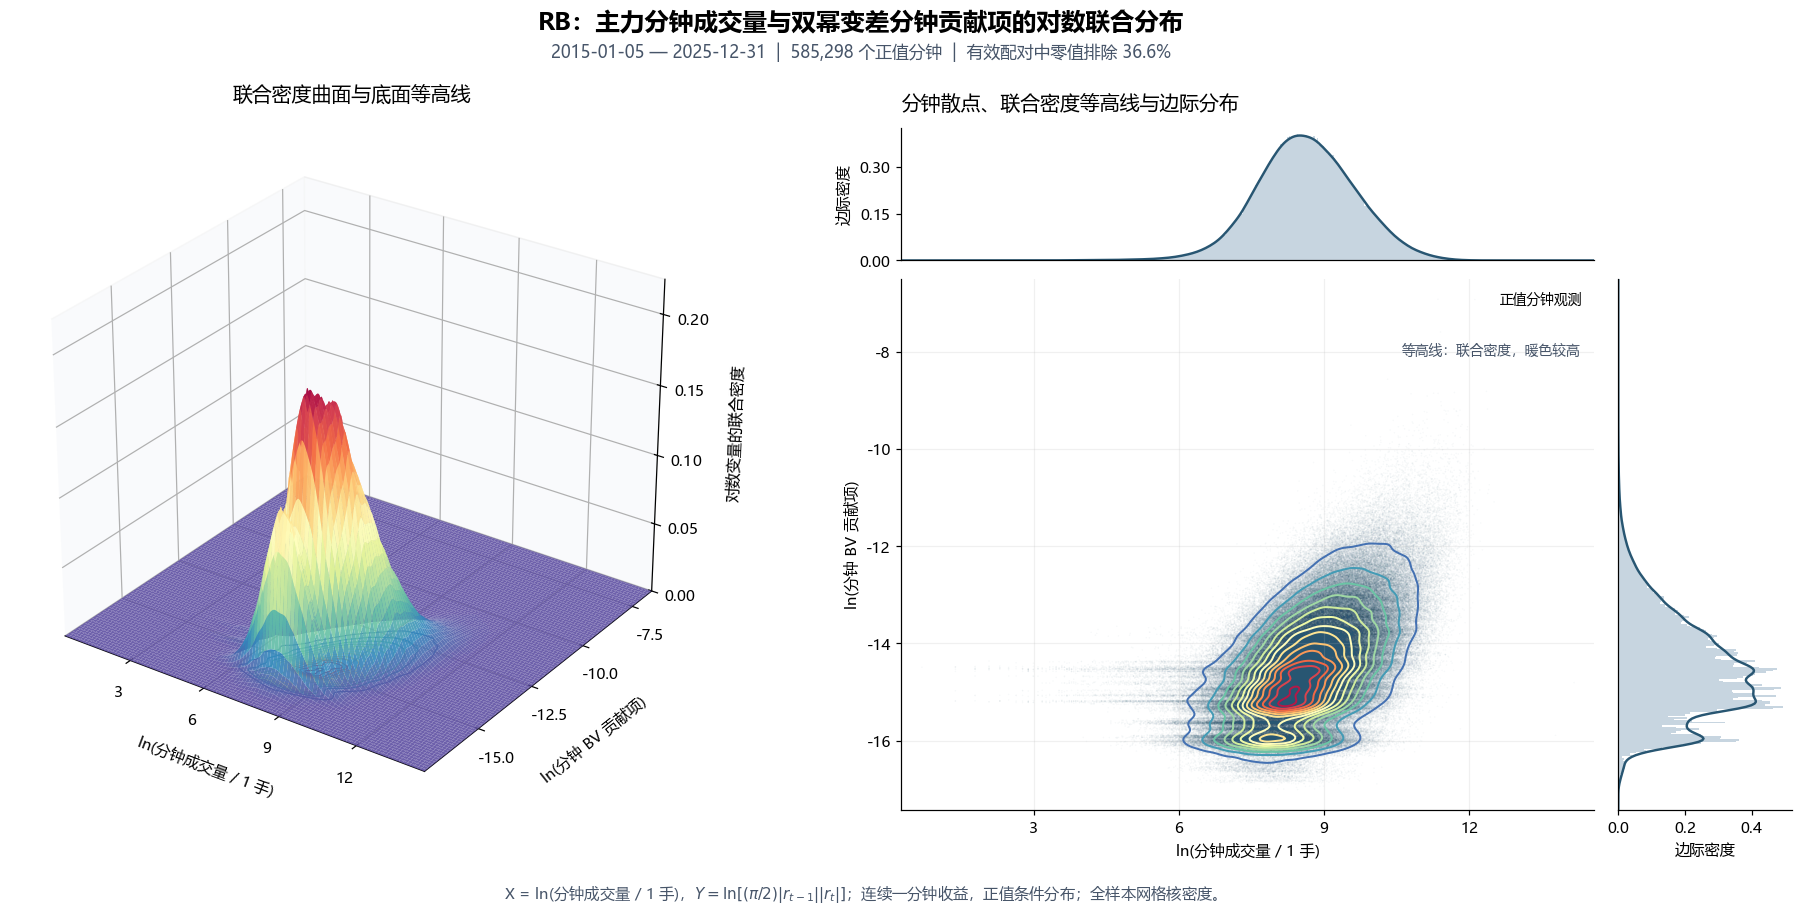

分钟对数联合分布图：E:\Latitude_Analytics_v2\00_draft_collection_01\testing_12/testing_12_rb_main_volume_bv_joint_distribution.png


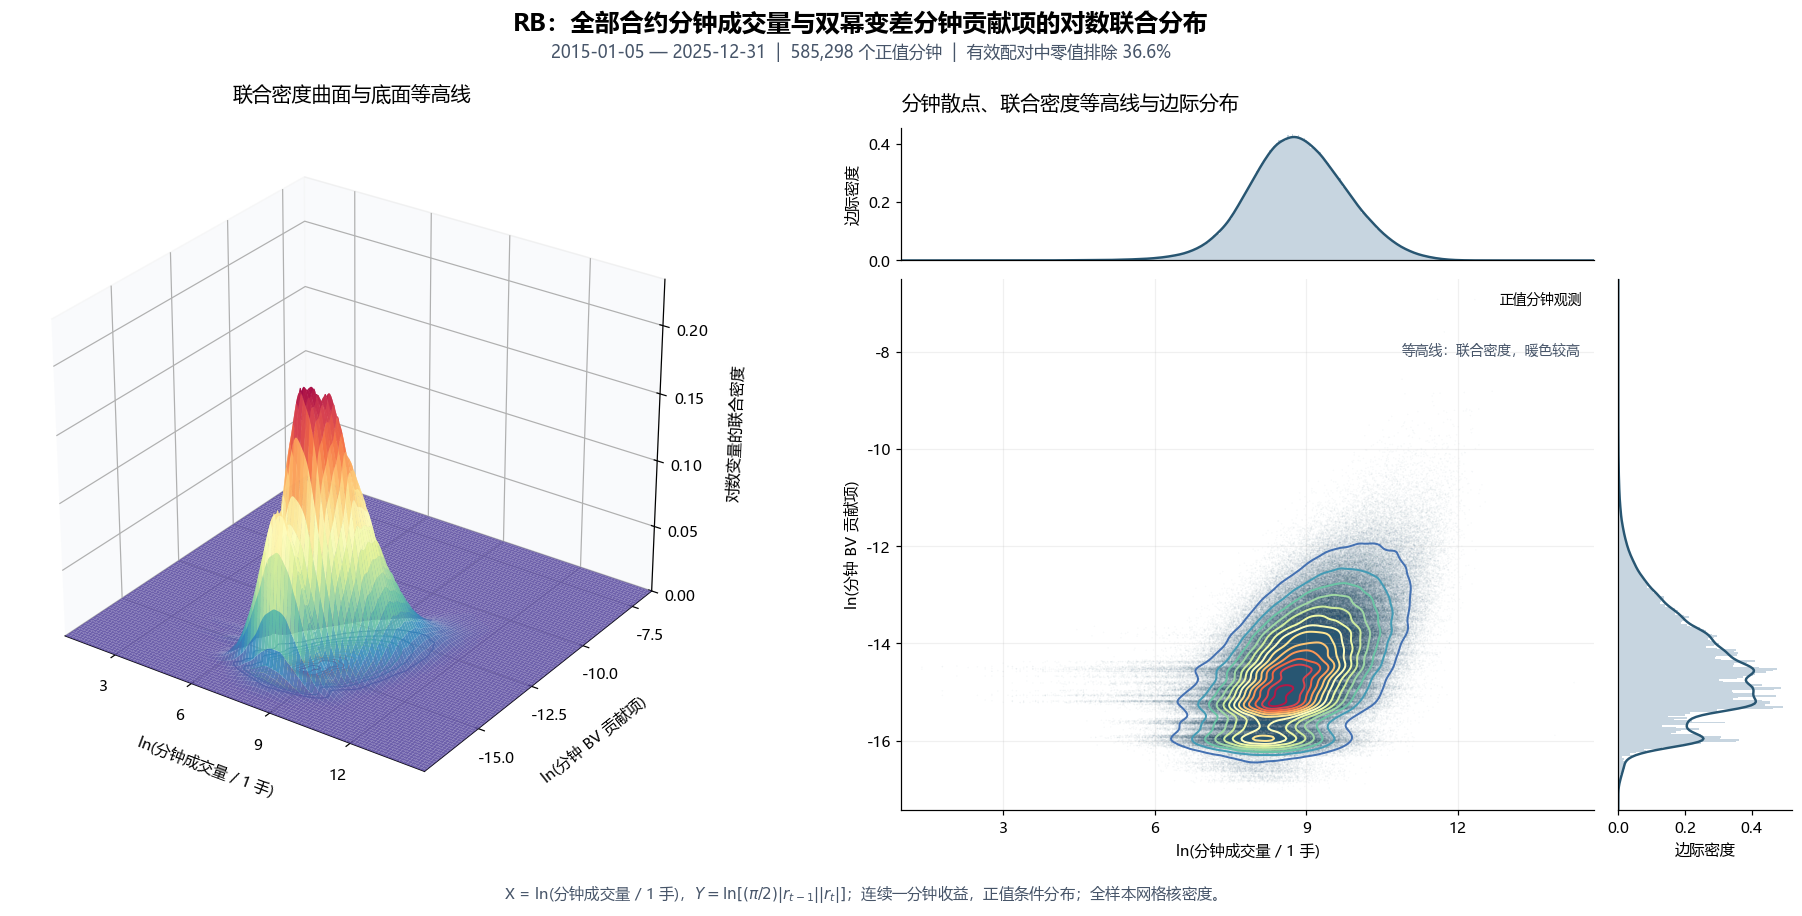

分钟对数联合分布图：E:\Latitude_Analytics_v2\00_draft_collection_01\testing_12/testing_12_rb_total_volume_bv_joint_distribution.png


In [17]:
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator, ScalarFormatter

minute_joint_distribution_figure_paths = []
for distribution in minute_joint_distribution_results:
    log_volume_values = distribution["log_volume_values"]
    log_bv_contribution_values = distribution["log_bv_contribution_values"]
    log_volume_mesh = distribution["log_volume_mesh"]
    log_bv_contribution_mesh = distribution["log_bv_contribution_mesh"]
    log_joint_density = distribution["log_joint_density"]
    density_peak = log_joint_density.max()
    contour_levels = density_peak * np.linspace(0.06, 0.96, 13)
    density_norm = Normalize(vmin=0, vmax=density_peak)
    density_cmap = "Spectral_r"

    joint_figure = plt.figure(figsize=(18, 8.5), facecolor="white")
    outer_grid = joint_figure.add_gridspec(
        1, 2, width_ratios=[1, 1.08], wspace=0.16,
        left=0.035, right=0.97, bottom=0.12, top=0.85,
    )
    surface_axis = joint_figure.add_subplot(outer_grid[0], projection="3d")
    marginal_grid = outer_grid[1].subgridspec(
        2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
        hspace=0.055, wspace=0.055,
    )
    scatter_axis = joint_figure.add_subplot(marginal_grid[1, 0])
    volume_marginal_axis = joint_figure.add_subplot(marginal_grid[0, 0], sharex=scatter_axis)
    bv_marginal_axis = joint_figure.add_subplot(marginal_grid[1, 1], sharey=scatter_axis)

    surface_axis.plot_surface(
        log_volume_mesh, log_bv_contribution_mesh, log_joint_density, cmap=density_cmap,
        norm=density_norm, rcount=150, ccount=150, linewidth=0,
        antialiased=True, alpha=0.9,
    )
    surface_axis.contour(
        log_volume_mesh, log_bv_contribution_mesh, log_joint_density, levels=contour_levels,
        zdir="z", offset=0, cmap=density_cmap, norm=density_norm, linewidths=0.8,
    )
    surface_axis.set(
        xlabel="ln(分钟成交量 / 1 手)", ylabel="ln(分钟 BV 贡献项)",
        zlabel="对数变量的联合密度", xlim=(distribution["log_volume_grid"][0], distribution["log_volume_grid"][-1]),
        ylim=(distribution["log_bv_contribution_grid"][0], distribution["log_bv_contribution_grid"][-1]), zlim=(0, density_peak * 1.12),
    )
    surface_axis.set_title("联合密度曲面与底面等高线", fontsize=13, pad=18)
    surface_axis.view_init(elev=28, azim=-55)
    surface_axis.set_box_aspect((1.05, 1.0, 0.85))
    surface_axis.xaxis.labelpad = 10
    surface_axis.yaxis.labelpad = 12
    surface_axis.zaxis.labelpad = 10
    surface_axis.xaxis.set_major_locator(MaxNLocator(5))
    surface_axis.yaxis.set_major_locator(MaxNLocator(5))
    surface_axis.zaxis.set_major_locator(MaxNLocator(5))
    density_formatter = ScalarFormatter(useMathText=True)
    density_formatter.set_powerlimits((-3, 3))
    surface_axis.zaxis.set_major_formatter(density_formatter)
    for axis in (surface_axis.xaxis, surface_axis.yaxis, surface_axis.zaxis):
        axis.pane.set_facecolor((0.96, 0.97, 0.98, 0.5))

    scatter_axis.scatter(
        log_volume_values, log_bv_contribution_values, s=1, color="#285672", alpha=0.035,
        edgecolors="none", label="正值分钟观测", rasterized=True,
    )
    scatter_axis.contour(
        log_volume_mesh, log_bv_contribution_mesh, log_joint_density, levels=contour_levels,
        cmap=density_cmap, norm=density_norm, linewidths=1.3,
    )
    scatter_axis.set(
        xlabel="ln(分钟成交量 / 1 手)", ylabel="ln(分钟 BV 贡献项)",
        xlim=(distribution["log_volume_grid"][0], distribution["log_volume_grid"][-1]),
        ylim=(distribution["log_bv_contribution_grid"][0], distribution["log_bv_contribution_grid"][-1]),
    )
    scatter_axis.grid(alpha=0.18)
    scatter_axis.legend(loc="upper right", frameon=False, fontsize=9)
    scatter_axis.xaxis.set_major_locator(MaxNLocator(5))
    scatter_axis.yaxis.set_major_locator(MaxNLocator(6))
    scatter_axis.ticklabel_format(axis="both", style="plain", useOffset=False)
    scatter_axis.text(
        0.98, 0.88, "等高线：联合密度，暖色较高", transform=scatter_axis.transAxes,
        ha="right", va="top", fontsize=9, color="#475569",
    )

    volume_marginal_axis.hist(log_volume_values, bins="fd", density=True, color="#b9cbd9", alpha=0.8)
    volume_marginal_axis.plot(
        distribution["log_volume_grid"], distribution["log_volume_marginal_density"],
        color="#285672", lw=1.6,
    )
    volume_marginal_axis.set_title("分钟散点、联合密度等高线与边际分布", loc="left", fontsize=13, pad=12)
    volume_marginal_axis.set_ylabel("边际密度", fontsize=10)
    volume_marginal_axis.set_ylim(bottom=0)
    volume_marginal_axis.tick_params(axis="x", labelbottom=False, bottom=False)
    volume_marginal_axis.yaxis.set_major_locator(MaxNLocator(3))
    volume_marginal_axis.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3), useMathText=True)

    bv_marginal_axis.hist(
        log_bv_contribution_values, bins="fd", density=True, orientation="horizontal",
        color="#b9cbd9", alpha=0.8,
    )
    bv_marginal_axis.plot(
        distribution["log_bv_contribution_marginal_density"], distribution["log_bv_contribution_grid"],
        color="#285672", lw=1.6,
    )
    bv_marginal_axis.set_xlabel("边际密度", fontsize=10)
    bv_marginal_axis.set_xlim(left=0)
    bv_marginal_axis.tick_params(axis="y", labelleft=False, left=False)
    bv_marginal_axis.xaxis.set_major_locator(MaxNLocator(3))
    bv_marginal_axis.ticklabel_format(axis="x", style="sci", scilimits=(-3, 3), useMathText=True)

    joint_figure.suptitle(
        f"RB：{distribution['volume_title']}与双幂变差分钟贡献项的对数联合分布",
        fontsize=16, fontweight="bold", y=0.975,
    )
    paired_dates = distribution["paired_minute_df"]["trading_date"]
    joint_figure.text(
        0.5, 0.925,
        f"{paired_dates.min():%Y-%m-%d} — {paired_dates.max():%Y-%m-%d}  |  "
        f"{len(paired_dates):,} 个正值分钟  |  有效配对中零值排除 {distribution['zero_pair_share']:.1%}",
        ha="center", fontsize=11, color="#475569",
    )
    joint_figure.text(
        0.5, 0.025,
        r"X = ln(分钟成交量 / 1 手)，$Y=\ln[(\pi/2)|r_{t-1}||r_t|]$；连续一分钟收益，正值条件分布；全样本网格核密度。",
        ha="center", fontsize=10, color="#475569",
    )
    joint_figure_path = output_dir / f"{distribution['figure_stem']}.png"
    if EXPORT_FILES:
        joint_figure.savefig(joint_figure_path, dpi=160, bbox_inches="tight", facecolor="white")
    if EXPORT_FILES:
        minute_joint_distribution_figure_paths.append(joint_figure_path)
    plt.show()
    if EXPORT_FILES:
        print(f"分钟对数联合分布图：{joint_figure_path}")
